# Combinatorial background with public candidate blinding

This version uses only the modern clustering sample. Singles remain unblinded for the data-driven background, while observed doublet candidates are filtered through the public blinding mask before signal-sensitive plots.

- build geometry with build_module_boxes
- convert your mask into fiducial boxes with fiducialize_boxes_from_mask
- fast batched MC generator:
- - continuous sampling (uniform in fiducial volumes)
- - voxelized sampling (snap to grid to emulate lattice spikes)
- - applies min_dist cut while still returning exactly N events
- computes angles with the same dz-ordering convention as data
- loads your HDF5 data, applies the same selection, and overlays plots

# Cell 0 — imports

In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

try:
    from tqdm.auto import tqdm
    TQDM_OK = True
except Exception:
    TQDM_OK = False
import os
import re
from pathlib import Path
import math

import json


### Cell 0.1 — figure saving helpers

In [2]:

# Cell 0.1 — figure saving helpers
OUTPUT_DIR = Path("double_blip_figures")
SAVE_FIGURES = True
FIG_DPI = 180

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Figures will be saved to: {OUTPUT_DIR.resolve()}")

_FIG_SAVE_COUNTER = {"n": 0}

def _slugify(text):
    text = str(text)
    text = re.sub(r"\$+", "", text)
    text = re.sub(r"[^A-Za-z0-9._-]+", "_", text).strip("._")
    return text or "figure"

def save_current_figure(name, fig=None, dpi=FIG_DPI, close=False):
    if not SAVE_FIGURES:
        return None
    _FIG_SAVE_COUNTER["n"] += 1
    stem = f"{_FIG_SAVE_COUNTER['n']:03d}_{_slugify(name)}"
    out = OUTPUT_DIR / f"{stem}.png"
    if fig is None:
        fig = plt.gcf()
    fig.savefig(out, dpi=dpi, bbox_inches="tight")
    print(f"Saved: {out}")
    if close:
        plt.close(fig)
    return out


Figures will be saved to: /home/bruno/combinatoryBg/blinding/double_blip_figures


### Cell 0.2 — analysis/blinding configuration

Edit only these paths/options when changing input samples. The rest of the notebook uses the canonical `summary`, `obs_doublets`, and `singles_mc` objects.


In [3]:
# Cell 0.2 — analysis/blinding configuration

# Modern clustering HDF5 file. Expected structure:
#   /events/<event_key>/{labels,x,y,z,...}
DATA_H5 = "data_unblinded.h5"

# Public circular-ROI blinding mask produced by make_doublet_roi_blinding_mask.py
# or make_doublet_blinding_mask_axis_symmetric.py in the hard-ROI-only version.
#
# This notebook uses the mask in two places:
#   1. observed doublet candidates are filtered by event_key using /blinding/mask["visible"]
#   2. singles-driven MC doublets receive the same circular ROI exclusion from the mask config
BLINDING_MASK_H5 = "blinding_new.h5"
USE_PUBLIC_BLINDING = True
STRICT_BLINDING_MASK = True
APPLY_ROI_TO_SINGLES_MC = True

# Normalization policy:
#   - do NOT normalize MC to observed doublet sidebands
#   - scale the singles-driven MC from the observed single-blip pool only
USE_SINGLE_BLIP_NORMALIZATION = True

print("Analysis input:", DATA_H5)
print("Public blinding mask:", BLINDING_MASK_H5 if USE_PUBLIC_BLINDING else "disabled")
print("Singles-driven MC ROI exclusion:", APPLY_ROI_TO_SINGLES_MC)


Analysis input: data_unblinded.h5
Public blinding mask: blinding_new.h5
Singles-driven MC ROI exclusion: True


# Cell 1 — geometry helpers

In [4]:
def build_module_boxes(Lx=60.0, Ly=120.0, Lz=60.0, gapx=6.0, gapz=5.0):
    """
    Build 2x2 modules centered at (+/-xoff, +/-zoff) with true face-to-face gaps gapx, gapz.
    Returns list of boxes dicts with xmin/xmax/ymin/ymax/zmin/zmax and module id.
    """
    hx, hy, hz = Lx/2, Ly/2, Lz/2
    xoff = (Lx + gapx)/2
    zoff = (Lz + gapz)/2

    boxes = []
    mid = 0
    for sx in (+1, -1):      # right, left
        for sz in (+1, -1):  # +z, -z
            boxes.append({
                "module": mid,
                "xmin": sx*xoff - hx,
                "xmax": sx*xoff + hx,
                "ymin": -hy,
                "ymax": +hy,
                "zmin": sz*zoff - hz,
                "zmax": sz*zoff + hz,
            })
            mid += 1
    return boxes


def fiducialize_boxes_from_mask(module_boxes, y_half=51.85, z_inner_abs=12.68, z_outer_abs=54.32):
    """
    Intersect each module box with:
      y in [-y_half, +y_half]
      z in [ z_inner_abs,  z_outer_abs] for +z modules
      z in [-z_outer_abs, -z_inner_abs] for -z modules
    """
    fid_boxes = []
    for b in module_boxes:
        fymin = max(b["ymin"], -y_half)
        fymax = min(b["ymax"], +y_half)
        if fymin >= fymax:
            continue

        zc = 0.5 * (b["zmin"] + b["zmax"])
        if zc >= 0:
            z_keep_min, z_keep_max = z_inner_abs, z_outer_abs
        else:
            z_keep_min, z_keep_max = -z_outer_abs, -z_inner_abs

        fzmin = max(b["zmin"], z_keep_min)
        fzmax = min(b["zmax"], z_keep_max)
        if fzmin >= fzmax:
            continue

        fid_boxes.append({
            "module": b["module"],
            "xmin": b["xmin"],
            "xmax": b["xmax"],
            "ymin": fymin,
            "ymax": fymax,
            "zmin": fzmin,
            "zmax": fzmax,
        })
    return fid_boxes

# Cell 2 — fast sampling from fiducial boxes (continuous + voxelized)

In [5]:
def _boxes_to_arrays(boxes):
    xmin = np.array([b["xmin"] for b in boxes], dtype=np.float32)
    xmax = np.array([b["xmax"] for b in boxes], dtype=np.float32)
    ymin = np.array([b["ymin"] for b in boxes], dtype=np.float32)
    ymax = np.array([b["ymax"] for b in boxes], dtype=np.float32)
    zmin = np.array([b["zmin"] for b in boxes], dtype=np.float32)
    zmax = np.array([b["zmax"] for b in boxes], dtype=np.float32)
    mod  = np.array([b["module"] for b in boxes], dtype=np.int32)
    vol  = (xmax-xmin)*(ymax-ymin)*(zmax-zmin)
    p    = vol / vol.sum()
    return xmin,xmax,ymin,ymax,zmin,zmax,mod,p


def sample_hits_in_boxes(rng, n, boxes_arrays, voxel_size=None):
    """
    Sample n points uniformly from a union of axis-aligned boxes, weighted by volume.
    If voxel_size is not None (float), snap x/y/z to a cubic voxel grid of that size.
    """
    xmin,xmax,ymin,ymax,zmin,zmax,mod,p = boxes_arrays
    k = rng.choice(len(p), size=n, replace=True, p=p)

    x = rng.uniform(xmin[k], xmax[k]).astype(np.float32)
    y = rng.uniform(ymin[k], ymax[k]).astype(np.float32)
    z = rng.uniform(zmin[k], zmax[k]).astype(np.float32)
    m = mod[k]

    if voxel_size is not None:
        vs = float(voxel_size)
        x = (np.round(x / vs) * vs).astype(np.float32)
        y = (np.round(y / vs) * vs).astype(np.float32)
        z = (np.round(z / vs) * vs).astype(np.float32)

        # Clamp back into box bounds (rounding can push you slightly outside)
        x = np.clip(x, xmin[k], xmax[k]).astype(np.float32)
        y = np.clip(y, ymin[k], ymax[k]).astype(np.float32)
        z = np.clip(z, zmin[k], zmax[k]).astype(np.float32)

    return x, y, z, m

# Cell 3 — angles computed exactly like your data (dz forced positive)

In [6]:
def angles_like_data(ax, ay, az, bx, by, bz):
    """
    Match data convention:
    - order the two points by z (so dz >= 0)
    - theta_z  = arccos(dz/r)
    - theta_zx = atan2(dx, dz)
    - theta_zy = atan2(dy, dz)
    """
    dz = bz - az
    swap = dz < 0
    if np.any(swap):
        ax2, ay2, az2 = ax.copy(), ay.copy(), az.copy()
        bx2, by2, bz2 = bx.copy(), by.copy(), bz.copy()
        ax2[swap], bx2[swap] = bx2[swap], ax2[swap]
        ay2[swap], by2[swap] = by2[swap], ay2[swap]
        az2[swap], bz2[swap] = bz2[swap], az2[swap]
        ax, ay, az, bx, by, bz = ax2, ay2, az2, bx2, by2, bz2

    dx = bx - ax
    dy = by - ay
    dz = bz - az
    r  = np.sqrt(dx*dx + dy*dy + dz*dz)

    theta_z  = np.arccos(dz / r)
    theta_zx = np.arctan2(dx, dz)
    theta_zy = np.arctan2(dy, dz)
    return theta_z.astype(np.float32), theta_zx.astype(np.float32), theta_zy.astype(np.float32)

# Cell 4 — batched generator with min_dist cut (returns exactly N)

In [7]:
def generate_doublets_batched(
    boxes_arrays,
    N=5_000_000,
    seed=123,
    batch_size=500_000,
    min_dist=10.0,
    voxel_size=None,
    store_max=2000,
    show_progress=True,
    oversample=1.30,
    return_r=False,
):
    rng = np.random.default_rng(seed)

    theta_z  = np.empty(N, dtype=np.float32)
    theta_zx = np.empty(N, dtype=np.float32)
    theta_zy = np.empty(N, dtype=np.float32)
    r_out = np.empty(N, dtype=np.float32) if return_r else None

    # sample indices to store (global)
    if store_max > 0:
        store_idx = rng.choice(N, size=min(store_max, N), replace=False)
        store_idx.sort()
    else:
        store_idx = np.array([], dtype=np.int64)
    stored_tracks = []
    store_ptr = 0

    # tqdm that updates every batch (and also every refill loop)
    pbar = None
    if show_progress and TQDM_OK:
        pbar = tqdm(total=N, desc="Generating doublets", unit="evt")

    accepted_total = 0
    tried_total = 0

    n_batches = (N + batch_size - 1) // batch_size
    for bi in range(n_batches):
        start = bi * batch_size
        end = min(N, (bi + 1) * batch_size)
        nb = end - start

        # preallocate for this batch
        ax = np.empty(nb, dtype=np.float32)
        ay = np.empty(nb, dtype=np.float32)
        az = np.empty(nb, dtype=np.float32)
        am = np.empty(nb, dtype=np.int32)

        bx = np.empty(nb, dtype=np.float32)
        by = np.empty(nb, dtype=np.float32)
        bz = np.empty(nb, dtype=np.float32)
        bm = np.empty(nb, dtype=np.int32)

        fill = 0
        while fill < nb:
            need = nb - fill
            m = int(np.ceil(need * oversample))

            ax0, ay0, az0, am0 = sample_hits_in_boxes(rng, m, boxes_arrays, voxel_size=voxel_size)
            bx0, by0, bz0, bm0 = sample_hits_in_boxes(rng, m, boxes_arrays, voxel_size=voxel_size)

            dx = bx0 - ax0
            dy = by0 - ay0
            dz = bz0 - az0
            dist = np.sqrt(dx*dx + dy*dy + dz*dz)

            tried_total += m
            ok = dist >= float(min_dist)
            n_ok = int(ok.sum())
            if n_ok == 0:
                # still update tqdm occasionally so it doesn't look "stuck"
                if pbar is not None:
                    pbar.set_postfix(acc=f"{accepted_total/max(tried_total,1):.3f}")
                    pbar.update(0)
                continue

            take = min(n_ok, need)
            idx_ok = np.flatnonzero(ok)[:take]

            ax[fill:fill+take] = ax0[idx_ok]
            ay[fill:fill+take] = ay0[idx_ok]
            az[fill:fill+take] = az0[idx_ok]
            am[fill:fill+take] = am0[idx_ok]

            bx[fill:fill+take] = bx0[idx_ok]
            by[fill:fill+take] = by0[idx_ok]
            bz[fill:fill+take] = bz0[idx_ok]
            bm[fill:fill+take] = bm0[idx_ok]

            fill += take
            accepted_total += take

            if pbar is not None:
                pbar.update(take)
                pbar.set_postfix(acc=f"{accepted_total/max(tried_total,1):.3f}")

        # angles (same as data convention)
        thz, thzx, thzy = angles_like_data(ax, ay, az, bx, by, bz)
        theta_z[start:end]  = thz
        theta_zx[start:end] = thzx
        theta_zy[start:end] = thzy

        if return_r:
            dx = bx - ax; dy = by - ay; dz = bz - az
            r_out[start:end] = np.sqrt(dx*dx + dy*dy + dz*dz).astype(np.float32)

        # store tracks for overlays (unchanged logic)
        while store_ptr < len(store_idx) and store_idx[store_ptr] < end:
            gi = store_idx[store_ptr]
            li = gi - start
            stored_tracks.append({
                "a": {"x": float(ax[li]), "y": float(ay[li]), "z": float(az[li]), "module": int(am[li])},
                "b": {"x": float(bx[li]), "y": float(by[li]), "z": float(bz[li]), "module": int(bm[li])},
                "theta_z": float(thz[li]),
                "theta_zx": float(thzx[li]),
                "theta_zy": float(thzy[li]),
            })
            store_ptr += 1

    if pbar is not None:
        pbar.close()

    if return_r:
        return theta_z, theta_zx, theta_zy, r_out, stored_tracks
    return theta_z, theta_zx, theta_zy, stored_tracks

# Cell 5 — data loader (matches selection; optional centroid)

In [8]:
def load_data_angles(
    h5_path,
    min_dist=10.0,
    use_centroid=False,
):
    theta_z_real = []
    theta_zx_real = []
    theta_zy_real = []

    with h5py.File(h5_path, "r") as f:
        for key in f["events"]:
            g = f["events"][key]
            labels = g["labels"][:]
            x = g["x"][:]
            y = g["y"][:]
            z = g["z"][:]

            geom_mask = (
                (y >= -51.85) & (y <= 51.85) &
                (((z >= 12.68) & (z <= 54.32)) | ((z >= -54.32) & (z <= -12.68)))
            )

            idx = np.where(geom_mask & (labels >= 0))[0]
            if idx.size < 2:
                continue

            labs = labels[idx]
            uniq = np.unique(labs)
            if uniq.size != 2:
                continue

            c0 = idx[labs == uniq[0]]
            c1 = idx[labs == uniq[1]]

            if use_centroid:
                x2 = np.array([x[c0].mean(), x[c1].mean()])
                y2 = np.array([y[c0].mean(), y[c1].mean()])
                z2 = np.array([z[c0].mean(), z[c1].mean()])
            else:
                # match your current behavior
                idx0 = c0[0]
                idx1 = c1[0]
                x2 = np.array([x[idx0], x[idx1]])
                y2 = np.array([y[idx0], y[idx1]])
                z2 = np.array([z[idx0], z[idx1]])

            dx = x2[1] - x2[0]
            dy = y2[1] - y2[0]
            dz = z2[1] - z2[0]
            dist = np.sqrt(dx*dx + dy*dy + dz*dz)
            if dist < float(min_dist):
                continue

            # same convention as data function: order by z
            order = np.argsort(z2)
            x2, y2, z2 = x2[order], y2[order], z2[order]
            dx, dy, dz = x2[1]-x2[0], y2[1]-y2[0], z2[1]-z2[0]
            r = np.sqrt(dx*dx + dy*dy + dz*dz)

            theta_z_real.append(np.arccos(dz / r))
            theta_zx_real.append(np.arctan2(dx, dz))
            theta_zy_real.append(np.arctan2(dy, dz))

    return (np.array(theta_z_real),
            np.array(theta_zx_real),
            np.array(theta_zy_real))

# Cell 6 — plotting overlay helpers

In [9]:
def hist_with_err(data, nbins=60, range=None):
    counts, edges = np.histogram(data, bins=nbins, range=range)
    centers = 0.5*(edges[1:] + edges[:-1])
    err = np.sqrt(counts)
    return counts, centers, edges, err


def chi2_ndf_pvalue_from_hists(data_counts, model_counts, n_fit_params=1, min_variance=1.0):
    """
    Simple binned chi2 using Poisson data variance.

    Parameters
    ----------
    data_counts : array-like
        Observed bin counts.
    model_counts : array-like
        Expected / model bin counts, already normalized as desired.
    n_fit_params : int
        Number of fitted parameters to subtract from NDF.
        Use 1 when the model is normalized to the data.
    min_variance : float
        Floor for the variance to avoid divide-by-zero in empty bins.

    Returns
    -------
    chi2, ndf, pval, mask
    """
    data_counts = np.asarray(data_counts, dtype=float)
    model_counts = np.asarray(model_counts, dtype=float)

    # Keep bins where at least one side has content
    mask = (data_counts > 0) | (model_counts > 0)
    if not np.any(mask):
        return np.nan, 0, np.nan, mask

    d = data_counts[mask]
    m = model_counts[mask]
    var = np.maximum(d, float(min_variance))

    chi2 = float(np.sum((d - m)**2 / var))
    ndf = int(mask.sum() - n_fit_params)
    if ndf <= 0:
        return chi2, ndf, np.nan, mask

    pval = float(scipy.stats.chi2.sf(chi2, ndf))
    return chi2, ndf, pval, mask


def _stats_label(chi2, ndf, pval):
    if not np.isfinite(chi2) or ndf <= 0 or not np.isfinite(pval):
        return "chi2/ndf = n/a, p = n/a"
    return fr"$\chi^2/\mathrm{{ndf}} = {chi2:.1f}/{ndf} = {chi2/ndf:.2f}$,  $p = {pval:.3g}$"


def overlay_hist(mc, data, nbins=60, title="", xlabel="angle (rad)", scale_to="mc"):
    """
    Legacy overlay helper.

    In the blinded workflow this helper no longer normalizes MC to the observed
    data by default. Use scale_to="mc" for raw MC counts, or pass an explicit
    numeric scale that was computed from the singles-based normalization.
    """
    mc = np.asarray(mc)
    data = np.asarray(data)

    mc = mc[np.isfinite(mc)]
    data = data[np.isfinite(data)]

    if len(mc) == 0 or len(data) == 0:
        print(f"Skipping {title}: one of the inputs is empty.")
        return

    finite_all = np.concatenate([mc, data])
    data_range = (float(np.min(finite_all)), float(np.max(finite_all)))

    counts_d, centers, edges, err_d = hist_with_err(data, nbins=nbins, range=data_range)
    counts_m, _ = np.histogram(mc, bins=edges)

    if scale_to == "data":
        raise ValueError("scale_to='data' is disabled in the blinded workflow. Use singles-based normalization.")
    elif scale_to == "mc":
        s = 1.0
        n_fit_params = 0
    else:
        s = float(scale_to)
        n_fit_params = 0

    model_scaled = counts_m.astype(float) * s
    chi2, ndf, pval, _ = chi2_ndf_pvalue_from_hists(counts_d, model_scaled, n_fit_params=n_fit_params)

    plt.figure(figsize=(10, 5))
    plt.hist(mc, bins=edges, histtype="step", label=f"MC (scale x{s:.3g})",
             weights=np.ones_like(mc, dtype=float) * s)
    plt.errorbar(
        centers, counts_d, yerr=err_d, fmt="o", markersize=4,
        label=f"public-visible data | {_stats_label(chi2, ndf, pval)}"
    )
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Counts")
    plt.legend(fontsize=9)
    plt.tight_layout()
    save_current_figure(title or "overlay_hist")
    plt.show()

    print(f"{title}")
    print(f"  public-visible data: {_stats_label(chi2, ndf, pval)}")


# Cell 7 — run everything (continuous + voxelized)

In [10]:
# Geometry
MODULE_BOXES = build_module_boxes(Lx=60, Ly=120, Lz=60, gapx=6, gapz=5)
FID_BOXES    = fiducialize_boxes_from_mask(MODULE_BOXES, y_half=51.85, z_inner_abs=12.68, z_outer_abs=54.32)
boxes_arrays = _boxes_to_arrays(FID_BOXES)

print("Modules:", len(MODULE_BOXES), " Fiducial boxes:", len(FID_BOXES))
for b in FID_BOXES:
    print(b)

min_dist = 10.0

# MC continuous
theta_z_mc, theta_zx_mc, theta_zy_mc, stored_tracks = generate_doublets_batched(
    boxes_arrays,
    N=20_000_000,
    seed=1,
    batch_size=400_000,
    min_dist=min_dist,
    voxel_size=None,     # continuous
    store_max=200000,
    show_progress=True,
)

# MC voxelized (optional; reduce N if slow)
theta_z_vox, theta_zx_vox, theta_zy_vox, _ = generate_doublets_batched(
    boxes_arrays,
    N=10_000_000,
    seed=2,
    batch_size=250_000,
    min_dist=min_dist,
    voxel_size=0.4,      # 1 cm voxel grid (tune)
    store_max=0,
    show_progress=True,
)

Modules: 4  Fiducial boxes: 4
{'module': 0, 'xmin': 3.0, 'xmax': 63.0, 'ymin': -51.85, 'ymax': 51.85, 'zmin': 12.68, 'zmax': 54.32}
{'module': 1, 'xmin': 3.0, 'xmax': 63.0, 'ymin': -51.85, 'ymax': 51.85, 'zmin': -54.32, 'zmax': -12.68}
{'module': 2, 'xmin': -63.0, 'xmax': -3.0, 'ymin': -51.85, 'ymax': 51.85, 'zmin': 12.68, 'zmax': 54.32}
{'module': 3, 'xmin': -63.0, 'xmax': -3.0, 'ymin': -51.85, 'ymax': 51.85, 'zmin': -54.32, 'zmax': -12.68}


Generating doublets:   0%|          | 0/20000000 [00:00<?, ?evt/s]

Generating doublets:   0%|          | 0/10000000 [00:00<?, ?evt/s]

# Cell 7.1 — legacy direct data loading disabled

This notebook now builds observed data arrays from the candidate summary plus the **public blinding mask**. Do not use `load_data_angles(...)` for signal-sensitive plots, because that bypasses blinding.


In [11]:
# Cell 7.1 — intentionally no direct raw-data angle loading here
#
# The public-visible observed sample is built in Cell 7.5 as `obs_doublets`.
# For convenience, the angle aliases `theta_z_data`, `theta_zx_data`, and
# `theta_zy_data` are also created there.
print("Skipping direct data angle loading; using public-blinded candidate arrays in Cell 7.5.")


Skipping direct data angle loading; using public-blinded candidate arrays in Cell 7.5.


### Cell 7.2 — multiplicity / Poisson / single-blip resampling helpers

This section adds three things on top of the original double-blip study:

1. **Cluster multiplicity per event** for each dataset, with Poisson overlays.
2. **A singles-driven combinatorial MC**, where synthetic doublets are built by sampling from the observed **single-cluster** population instead of from a uniform spatial prior.
3. **A simple Ar39 rate estimate** for the fiducial volume, so the observed multiplicity can be compared with a physically motivated baseline.

A few implementation notes:
- The fiducial selection follows the same `y/z` acceptance already used above.
- "Single-blip distribution" means clusters taken from events with exactly **one accepted cluster** in the fiducial volume.
- Charge / energy is loaded in a best-effort way by looking for common charge-like dataset names in each event group. If no compatible quantity is found, the rate/geometry studies still run and the energy plots are skipped.
- The Ar39 comparison needs an **event window duration**. Leave `EVENT_WINDOW_S = None` to skip that overlay, or set it to the readout window used to build these event files.


In [12]:
import scipy.stats

# Cell 7.2 — multiplicity / Poisson / single-blip resampling helpers

AR39_ACTIVITY_BQ_PER_KG = 0.97      # atmospheric argon, Bq / kg
LAR_DENSITY_G_PER_CM3 = 1.3954      # liquid argon near 87 K
EVENT_WINDOW_S = 20e-6               # e.g. 2.2e-3 if you want an Ar39 overlay
AR39_RECO_EFFICIENCY = 1.0          # optional effective acceptance / reconstruction factor
SINGLES_MC_TARGET = 200_000         # accepted synthetic doublets to build from singles
SINGLE_ENERGY_KEYS = [
    "energy", "E", "adc", "adcs", "q", "Q", "charge", "charges", "dq", "de", "nhit", "nhits"
]


def fiducial_geom_mask_from_arrays(x, y, z):
    return (
        (y >= -51.85) & (y <= 51.85) &
        (((z >= 12.68) & (z <= 54.32)) | ((z >= -54.32) & (z <= -12.68)))
    )


def infer_cluster_energy(event_group, cluster_indices, candidate_keys=SINGLE_ENERGY_KEYS):
    """
    Best-effort cluster energy / charge estimator.

    Returns the sum over the first charge-like dataset found in the event group.
    If nothing suitable is present, returns np.nan.
    """
    n_points = len(event_group["x"])

    for key in candidate_keys:
        if key not in event_group:
            continue

        arr = event_group[key][:]
        arr = np.asarray(arr)

        # Per-point quantity: sum over hits in the cluster
        if arr.ndim == 1 and len(arr) == n_points:
            try:
                return float(np.nansum(arr[cluster_indices]))
            except Exception:
                pass

        # Already one value per event / cluster-like array — not safe to assume mapping here
        # so we skip it rather than risk a wrong interpretation.

    return np.nan


def _event_time_from_group(group):
    """
    Try to recover an event time / integration window from the group.
    This is only a helper; returning None is perfectly fine.
    """
    attr_candidates = [
        "event_window_s", "window_s", "readout_window_s", "dt_s",
        "duration_s", "livetime_s", "trigger_window_s"
    ]
    for k in attr_candidates:
        if k in group.attrs:
            try:
                return float(group.attrs[k])
            except Exception:
                pass
    return None


def load_cluster_event_summary(h5_path, use_centroid=True):
    """
    Parse all events and summarize accepted fiducial clusters.

    Returns a dict with:
      - multiplicities: number of accepted clusters per event
      - singles: pool of clusters from events with multiplicity == 1
      - doublets: accepted events with multiplicity == 2
      - triplets: accepted events with multiplicity == 3
      - all_clusters: all accepted fiducial clusters regardless of event multiplicity
      - event_windows_s: optional event windows recovered from attrs when present
    """
    multiplicities = []
    singles = []
    doublets = []
    triplets = []
    all_clusters = []
    event_windows_s = []

    with h5py.File(h5_path, "r") as f:
        events = f["events"]
        keys = list(events.keys())

        iterable = tqdm(keys, desc=f"Summarizing {Path(h5_path).name}") if TQDM_OK else keys
        for key in iterable:
            g = events[key]
            labels = np.asarray(g["labels"][:])
            x = np.asarray(g["x"][:], dtype=float)
            y = np.asarray(g["y"][:], dtype=float)
            z = np.asarray(g["z"][:], dtype=float)

            geom_mask = fiducial_geom_mask_from_arrays(x, y, z)
            idx = np.where(geom_mask & (labels >= 0))[0]
            event_time = _event_time_from_group(g)
            if event_time is not None:
                event_windows_s.append(event_time)

            if idx.size == 0:
                multiplicities.append(0)
                continue

            labs = labels[idx]
            uniq = np.unique(labs)
            clusters = []
            for lab in uniq:
                cidx = idx[labs == lab]
                if cidx.size == 0:
                    continue

                if use_centroid:
                    pos = np.array([x[cidx].mean(), y[cidx].mean(), z[cidx].mean()], dtype=float)
                else:
                    pos = np.array([x[cidx[0]], y[cidx[0]], z[cidx[0]]], dtype=float)

                energy = infer_cluster_energy(g, cidx)
                cluster = {
                    "event_key": key,
                    "label": int(lab),
                    "npts": int(cidx.size),
                    "x": float(pos[0]),
                    "y": float(pos[1]),
                    "z": float(pos[2]),
                    "energy": float(energy) if np.isfinite(energy) else np.nan,
                }
                clusters.append(cluster)
                all_clusters.append(cluster)

            multiplicities.append(len(clusters))

            if len(clusters) == 1:
                singles.append(clusters[0])
            elif len(clusters) == 2:
                doublets.append(clusters)
            elif len(clusters) == 3:
                triplets.append(clusters)

    return {
        "multiplicities": np.asarray(multiplicities, dtype=int),
        "singles": singles,
        "doublets": doublets,
        "triplets": triplets,
        "all_clusters": all_clusters,
        "event_windows_s": np.asarray(event_windows_s, dtype=float),
    }


def poisson_pmf(k, lam):
    """
    Numerically stable Poisson PMF using log-space:
        P(k; lam) = exp(-lam + k*log(lam) - lgamma(k+1))
    """
    k = np.asarray(k, dtype=int)
    out = np.zeros_like(k, dtype=float)

    if lam is None or lam < 0:
        return out

    if lam == 0:
        out[k == 0] = 1.0
        return out

    for i, kk in enumerate(k):
        out[i] = math.exp(-lam + kk * math.log(lam) - math.lgamma(kk + 1))

    return out

def fiducial_volume_cm3(boxes):
    vol = 0.0
    for b in boxes:
        vol += (b["xmax"] - b["xmin"]) * (b["ymax"] - b["ymin"]) * (b["zmax"] - b["zmin"])
    return float(vol)


def ar39_lambda_for_window(boxes, event_window_s, activity_bq_per_kg=AR39_ACTIVITY_BQ_PER_KG,
                           density_g_per_cm3=LAR_DENSITY_G_PER_CM3, reco_efficiency=AR39_RECO_EFFICIENCY):
    vol_cm3 = fiducial_volume_cm3(boxes)
    mass_kg = vol_cm3 * density_g_per_cm3 / 1000.0
    rate_hz = activity_bq_per_kg * mass_kg
    lam = rate_hz * float(event_window_s) * float(reco_efficiency)
    return lam, mass_kg, vol_cm3, rate_hz


def plot_multiplicity_poisson(multiplicities, title, lam_ref=None, lam_ref_label=None, kmax_show=None):
    multiplicities = np.asarray(multiplicities)

    if len(multiplicities) == 0:
        print(f"No events found for {title}")
        return

    if kmax_show is None:
        # safer default than max(multiplicities), which can be dominated by outliers
        kmax_show = max(8, int(np.percentile(multiplicities, 99.5)))
        kmax_show = min(kmax_show, int(np.max(multiplicities)))

    ks = np.arange(0, kmax_show + 1)
    counts = np.array([(multiplicities == k).sum() for k in ks], dtype=float)
    errs = np.sqrt(counts)
    n_evt = len(multiplicities)
    lam_hat = float(np.mean(multiplicities))

    plt.figure(figsize=(8, 5))
    plt.errorbar(ks, counts, yerr=errs, fmt="o", capsize=3, label=f"Observed ({n_evt} events)")

    model_obs = n_evt * poisson_pmf(ks, lam_hat)
    plt.plot(ks, model_obs, linewidth=2, label=fr"Poisson with $\lambda=\langle n \rangle={lam_hat:.3f}$")

    if lam_ref is not None:
        model_ref = n_evt * poisson_pmf(ks, lam_ref)
        lbl = lam_ref_label or fr"Reference Poisson ($\lambda={lam_ref:.3f}$)"
        plt.plot(ks, model_ref, "--", linewidth=2, label=lbl)

    plt.xlabel("accepted clusters per event")
    plt.ylabel("number of events")
    plt.title(title)
    plt.yscale("log")
    plt.ylim(bottom=0.1) 
    plt.legend()
    plt.tight_layout()
    save_current_figure(title)
    plt.show()

    frac = lambda n: float(np.mean(multiplicities == n))
    tail2 = float(np.mean(multiplicities >= 2))
    tail3 = float(np.mean(multiplicities >= 3))
    print(f"{title}")
    print(f"  mean multiplicity = {lam_hat:.5f}")
    print(f"  P(n=0,1,2,3) obs  = {frac(0):.5f}, {frac(1):.5f}, {frac(2):.5f}, {frac(3):.5f}")
    print(f"  P(n>=2), P(n>=3) = {tail2:.5f}, {tail3:.5f}")
    if lam_ref is not None:
        pmf_ref = poisson_pmf(np.arange(4), lam_ref)
        print(f"  Ref lambda        = {lam_ref:.5f}")
        print(f"  Ref P(n=0,1,2,3)  = {pmf_ref[0]:.5f}, {pmf_ref[1]:.5f}, {pmf_ref[2]:.5f}, {pmf_ref[3]:.5f}")

def clusters_to_arrays(clusters):
    if len(clusters) == 0:
        return {
            "x": np.array([]), "y": np.array([]), "z": np.array([]),
            "energy": np.array([]), "npts": np.array([])
        }
    return {
        "x": np.array([c["x"] for c in clusters], dtype=float),
        "y": np.array([c["y"] for c in clusters], dtype=float),
        "z": np.array([c["z"] for c in clusters], dtype=float),
        "energy": np.array([c["energy"] for c in clusters], dtype=float),
        "npts": np.array([c["npts"] for c in clusters], dtype=float),
    }


def build_doublet_arrays_from_cluster_pairs(cluster_pairs, min_dist=10.0, sort_by_z=True):
    dx, dy, dz = [], [], []
    theta_z, theta_zx, theta_zy = [], [], []
    e0, e1, esum, eabsdiff = [], [], [], []
    npts0, npts1 = [], []

    for c0, c1 in cluster_pairs:
        p0 = np.array([c0["x"], c0["y"], c0["z"]], dtype=float)
        p1 = np.array([c1["x"], c1["y"], c1["z"]], dtype=float)
        if sort_by_z and (p1[2] < p0[2]):
            p0, p1 = p1, p0
            c0, c1 = c1, c0

        d = p1 - p0
        dist = np.linalg.norm(d)
        if dist < float(min_dist):
            continue

        dx.append(d[0]); dy.append(d[1]); dz.append(d[2])
        theta_z.append(np.arccos(np.clip(d[2] / dist, -1.0, 1.0)))
        theta_zx.append(np.arctan2(d[0], d[2]))
        theta_zy.append(np.arctan2(d[1], d[2]))

        ee0 = c0.get("energy", np.nan)
        ee1 = c1.get("energy", np.nan)
        e0.append(ee0); e1.append(ee1)
        esum.append(ee0 + ee1 if np.isfinite(ee0) and np.isfinite(ee1) else np.nan)
        eabsdiff.append(abs(ee1 - ee0) if np.isfinite(ee0) and np.isfinite(ee1) else np.nan)
        npts0.append(c0.get("npts", np.nan)); npts1.append(c1.get("npts", np.nan))

    return {
        "dx": np.asarray(dx), "dy": np.asarray(dy), "dz": np.asarray(dz),
        "theta_z": np.asarray(theta_z), "theta_zx": np.asarray(theta_zx), "theta_zy": np.asarray(theta_zy),
        "e0": np.asarray(e0, dtype=float), "e1": np.asarray(e1, dtype=float),
        "esum": np.asarray(esum, dtype=float), "eabsdiff": np.asarray(eabsdiff, dtype=float),
        "npts0": np.asarray(npts0, dtype=float), "npts1": np.asarray(npts1, dtype=float),
    }


def monte_carlo_doublets_from_singles(single_clusters, n_accept=100_000, min_dist=10.0, sort_by_z=True,
                                      seed=1234, allow_same_source_event=True, max_trials_factor=50):
    """
    Build synthetic doublets by independently drawing from the observed single-cluster pool.
    """
    rng = np.random.default_rng(seed)
    singles = list(single_clusters)
    if len(singles) < 2:
        raise ValueError("Need at least two single clusters to build a singles-driven MC.")

    accepted_pairs = []
    trials = 0
    max_trials = int(max_trials_factor * n_accept)

    while len(accepted_pairs) < n_accept and trials < max_trials:
        trials += 1
        i0 = rng.integers(0, len(singles))
        i1 = rng.integers(0, len(singles) - 1)
        if i1 >= i0:
            i1 += 1
        c0 = singles[i0]
        c1 = singles[i1]

        if (not allow_same_source_event) and (c0["event_key"] == c1["event_key"]):
            continue

        p0 = np.array([c0["x"], c0["y"], c0["z"]], dtype=float)
        p1 = np.array([c1["x"], c1["y"], c1["z"]], dtype=float)
        if np.linalg.norm(p1 - p0) < float(min_dist):
            continue

        accepted_pairs.append((c0, c1))

    if len(accepted_pairs) < n_accept:
        print(f"Warning: requested {n_accept} accepted singles-MC doublets, got {len(accepted_pairs)}")

    return build_doublet_arrays_from_cluster_pairs(accepted_pairs, min_dist=min_dist, sort_by_z=sort_by_z)


def overlay_hist_simple(
    data_a, data_b, label_a, label_b, title, xlabel,
    bins=60, density=True, range=None, annotate_stats=True,
    model_expected_total=None,
):
    """
    Basic shape/count overlay. This placeholder is overridden in Cell 7.2b with
    the full singles-normalized version, but it already avoids normalizing MC to
    the observed doublet count.
    """
    a = np.asarray(data_a)
    b = np.asarray(data_b)
    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]
    if len(a) == 0 or len(b) == 0:
        print(f"Skipping {title}: one of the inputs is empty.")
        return

    if range is None:
        allv = np.concatenate([a, b])
        range = (float(np.min(allv)), float(np.max(allv)))

    counts_a, edges = np.histogram(a, bins=bins, range=range)
    counts_b, _ = np.histogram(b, bins=edges)
    centers = 0.5 * (edges[:-1] + edges[1:])
    widths = np.diff(edges)

    if model_expected_total is not None and counts_b.sum() > 0:
        model_b = counts_b.astype(float) * (float(model_expected_total) / counts_b.sum())
        chi2, ndf, pval, _ = chi2_ndf_pvalue_from_hists(counts_a, model_b, n_fit_params=0)
        stats = _stats_label(chi2, ndf, pval)
    else:
        model_b = counts_b.astype(float)
        stats = "shape-only"

    if density:
        norm_a = max(len(a), 1) * widths
        y_a = counts_a / norm_a
        yerr_a = np.sqrt(counts_a) / norm_a
        ylabel = "normalized counts"
    else:
        y_a = counts_a.astype(float)
        yerr_a = np.sqrt(counts_a)
        ylabel = "counts"

    plt.figure(figsize=(7, 5))
    plt.errorbar(
        centers, y_a, yerr=yerr_a, fmt="o", markersize=4, capsize=2,
        label=f"{label_a} | {stats}"
    )

    if density:
        plt.hist(b, bins=edges, density=True, histtype="step", linewidth=2,
                 linestyle="--", label=label_b)
    else:
        plt.step(edges[:-1], model_b, where="post", linestyle="--", linewidth=2, label=label_b)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(fontsize=9)
    plt.tight_layout()
    save_current_figure(title)
    plt.show()

    print(f"{title}")
    print(f"  {stats}")


### Cell 7.2b — public blinding-mask helpers


In [13]:
# Cell 7.2b — public circular-ROI blinding helpers

def _decode_h5_string_array(arr):
    out = []
    for x in arr:
        if isinstance(x, bytes):
            out.append(x.decode("utf-8", errors="replace"))
        else:
            out.append(str(x))
    return np.asarray(out, dtype=object)


def load_public_blinding_mask(mask_h5_path):
    """
    Load the public candidate-level circular-ROI blinding mask.

    Expected structure:
        /blinding/event_key
        /blinding/mask

    Expected mask fields:
        candidate_id, event_index, blind_mask, visible

    The mask hides observed doublet candidates in the hard ROI. The config_json
    attribute stores the same circular ROI definition used by the mask script;
    this notebook reuses that config to apply the same ROI exclusion to the
    singles-driven MC doublet distribution.
    """
    mask_h5_path = Path(mask_h5_path)
    if not mask_h5_path.exists():
        raise FileNotFoundError(
            f"Public blinding mask not found: {mask_h5_path}\n"
            "Create it with the hard-ROI blinding script, or set USE_PUBLIC_BLINDING=False "
            "only for deliberate unblinded/debug work."
        )

    with h5py.File(mask_h5_path, "r") as f:
        g = f["blinding"]
        event_keys = _decode_h5_string_array(g["event_key"][:])
        mask = g["mask"][:]
        attrs = dict(g.attrs)

    visible = np.asarray(mask["visible"], dtype=bool)
    blind_mask = np.asarray(mask["blind_mask"], dtype=bool)
    candidate_id = np.asarray(mask["candidate_id"], dtype=int)

    if len(event_keys) != len(visible):
        raise ValueError("Public blinding mask has mismatched event_key and mask lengths.")

    visible_by_event_key = {}
    blind_by_event_key = {}

    for k, vis, blind in zip(event_keys, visible, blind_mask):
        k = str(k)
        if k in visible_by_event_key:
            raise ValueError(f"Duplicate event_key in blinding mask: {k}")
        visible_by_event_key[k] = bool(vis)
        blind_by_event_key[k] = bool(blind)

    cfg = {}
    if "config_json" in attrs:
        raw = attrs["config_json"]
        if isinstance(raw, bytes):
            raw = raw.decode("utf-8", errors="replace")
        cfg = json.loads(str(raw))

    return {
        "event_key": event_keys,
        "candidate_id": candidate_id,
        "visible": visible,
        "blind_mask": blind_mask,
        "visible_by_event_key": visible_by_event_key,
        "blind_by_event_key": blind_by_event_key,
        "attrs": attrs,
        "config": cfg,
    }


def circular_roi_config_from_public_mask(mask_h5_path):
    """Extract the circular projected-angle ROI settings from a public mask file."""
    public = load_public_blinding_mask(mask_h5_path)
    cfg = public.get("config", {})

    # Support both the newer hard-ROI names and a few older names from earlier prototypes.
    theta_radius_deg = cfg.get("theta_radius_deg", cfg.get("theta_cone_deg", None))
    if theta_radius_deg is None:
        raise KeyError(
            "Could not find theta_radius_deg/theta_cone_deg in mask config_json. "
            "Regenerate the mask with the hard circular-ROI blinding script."
        )

    return {
        "theta_radius_deg": float(theta_radius_deg),
        "center_zx_deg": float(cfg.get("center_zx_deg", 0.0)),
        "center_zy_deg": float(cfg.get("center_zy_deg", 0.0)),
        "axis_symmetric_roi": bool(cfg.get("axis_symmetric_roi", True)),
    }


def select_doublet_arrays(obs, selection):
    """Apply a boolean selection to every per-candidate array in an obs_doublets dict."""
    selection = np.asarray(selection, dtype=bool)
    out = {}

    for k, v in obs.items():
        arr = np.asarray(v)
        if arr.shape[0] == selection.shape[0]:
            out[k] = arr[selection]
        else:
            out[k] = v

    return out


def _angle_delta(a, center):
    """Smallest signed angular difference a - center, wrapped to [-pi, pi)."""
    a = np.asarray(a, dtype=float)
    return (a - center + np.pi) % (2.0 * np.pi) - np.pi


def axis_symmetric_projected_angles(dx, dy, dz, *, axis_symmetric=True):
    """
    Projected angles used by the hard circular ROI.

    If axis_symmetric=True, the doublet is treated as an axis rather than a directed
    arrow, so +z and -z aligned pairs are both considered signal-like.
    """
    dx = np.asarray(dx, dtype=float)
    dy = np.asarray(dy, dtype=float)
    dz = np.asarray(dz, dtype=float)

    if axis_symmetric:
        flip = dz < 0
        dx = np.where(flip, -dx, dx)
        dy = np.where(flip, -dy, dy)
        dz = np.abs(dz)

    theta_zx = np.arctan2(dx, dz)
    theta_zy = np.arctan2(dy, dz)
    return theta_zx, theta_zy


def circular_roi_mask_for_doublet_arrays(
    obs,
    *,
    theta_radius_deg,
    center_zx_deg=0.0,
    center_zy_deg=0.0,
    axis_symmetric=True,
):
    """
    Return True for doublets inside the circular projected-angle ROI.
    """
    theta_zx, theta_zy = axis_symmetric_projected_angles(
        obs["dx"], obs["dy"], obs["dz"], axis_symmetric=axis_symmetric
    )
    d_zx = _angle_delta(theta_zx, np.deg2rad(center_zx_deg))
    d_zy = _angle_delta(theta_zy, np.deg2rad(center_zy_deg))
    radius = np.sqrt(d_zx * d_zx + d_zy * d_zy)
    return radius <= np.deg2rad(theta_radius_deg)


def apply_circular_roi_exclusion_to_doublet_arrays(
    obs,
    *,
    theta_radius_deg,
    center_zx_deg=0.0,
    center_zy_deg=0.0,
    axis_symmetric=True,
    label="sample",
    use_public_blinding=True,
):
    """
    Apply the hard circular ROI exclusion to an arbitrary doublet-array dict.

    This is used for the singles-driven MC. It does not need event_key; it simply
    applies the same angular ROI definition stored in the observed-data mask file.
    """
    if not use_public_blinding:
        print(f"{label}: ROI exclusion disabled.")
        return obs, np.ones(len(obs["dx"]), dtype=bool)

    in_roi = circular_roi_mask_for_doublet_arrays(
        obs,
        theta_radius_deg=theta_radius_deg,
        center_zx_deg=center_zx_deg,
        center_zy_deg=center_zy_deg,
        axis_symmetric=axis_symmetric,
    )
    keep = ~in_roi
    out = select_doublet_arrays(obs, keep)
    print(f"{label}: circular ROI exclusion applied.")
    return out, keep


def build_doublet_arrays_from_cluster_pairs(cluster_pairs, min_dist=10.0, sort_by_z=True):
    """
    Build per-candidate arrays from event-level two-cluster pairs.

    Important: this stores `event_key`, which is the join key used by the
    public blinding mask for observed doublets.
    """
    event_key = []
    dx, dy, dz = [], [], []
    theta_z, theta_zx, theta_zy = [], [], []
    e0, e1, esum, eabsdiff = [], [], [], []
    npts0, npts1 = [], []

    for c0, c1 in cluster_pairs:
        p0 = np.array([c0["x"], c0["y"], c0["z"]], dtype=float)
        p1 = np.array([c1["x"], c1["y"], c1["z"]], dtype=float)

        if sort_by_z and (p1[2] < p0[2]):
            p0, p1 = p1, p0
            c0, c1 = c1, c0

        d = p1 - p0
        dist = np.linalg.norm(d)
        if dist < float(min_dist):
            continue

        dx.append(d[0])
        dy.append(d[1])
        dz.append(d[2])

        theta_z.append(np.arccos(np.clip(d[2] / dist, -1.0, 1.0)))
        theta_zx.append(np.arctan2(d[0], d[2]))
        theta_zy.append(np.arctan2(d[1], d[2]))

        ee0 = c0.get("energy", np.nan)
        ee1 = c1.get("energy", np.nan)

        e0.append(ee0)
        e1.append(ee1)
        esum.append(ee0 + ee1 if np.isfinite(ee0) and np.isfinite(ee1) else np.nan)
        eabsdiff.append(abs(ee1 - ee0) if np.isfinite(ee0) and np.isfinite(ee1) else np.nan)

        npts0.append(c0.get("npts", np.nan))
        npts1.append(c1.get("npts", np.nan))
        event_key.append(str(c0["event_key"]))

    return {
        "event_key": np.asarray(event_key, dtype=object),
        "dx": np.asarray(dx, dtype=float),
        "dy": np.asarray(dy, dtype=float),
        "dz": np.asarray(dz, dtype=float),
        "theta_z": np.asarray(theta_z, dtype=float),
        "theta_zx": np.asarray(theta_zx, dtype=float),
        "theta_zy": np.asarray(theta_zy, dtype=float),
        "e0": np.asarray(e0, dtype=float),
        "e1": np.asarray(e1, dtype=float),
        "esum": np.asarray(esum, dtype=float),
        "eabsdiff": np.asarray(eabsdiff, dtype=float),
        "npts0": np.asarray(npts0, dtype=float),
        "npts1": np.asarray(npts1, dtype=float),
    }


def apply_public_blinding_to_doublet_arrays(
    obs,
    mask_h5_path=None,
    *,
    label="sample",
    strict=True,
    use_public_blinding=True,
):
    """
    Keep only observed candidates marked visible in the public blinding mask.

    This is only for observed doublet candidates, where event_key is meaningful.
    Synthetic singles-driven MC doublets are blinded with
    apply_circular_roi_exclusion_to_doublet_arrays(...).
    """
    if (not use_public_blinding) or (mask_h5_path is None):
        print(f"{label}: public blinding disabled.")
        return obs

    public = load_public_blinding_mask(mask_h5_path)

    if "event_key" not in obs:
        raise KeyError("obs doublet arrays do not contain event_key. Re-run the helper cell above.")

    keys = np.asarray(obs["event_key"]).astype(str)
    visible = np.zeros(len(keys), dtype=bool)
    missing = []

    for i, key in enumerate(keys):
        if key not in public["visible_by_event_key"]:
            missing.append(key)
            # Non-strict mode keeps missing entries visible to avoid silent data loss.
            visible[i] = True
        else:
            visible[i] = public["visible_by_event_key"][key]

    if missing and strict:
        raise RuntimeError(
            f"{label}: {len(missing)} post-min_dist doublets are missing from the public mask. "
            "This usually means the mask was made with different min_dist/use_centroid/fiducial settings. "
            f"Example missing key: {missing[0]}"
        )

    out = select_doublet_arrays(obs, visible)

    print(f"{label}: public candidate mask applied.")
    if missing:
        print(f"  warning: {len(missing)} candidates were missing from the mask and kept visible because strict=False")

    return out


def monte_carlo_doublets_from_singles(
    single_clusters,
    n_accept=100_000,
    min_dist=10.0,
    sort_by_z=True,
    seed=1234,
    allow_same_source_event=True,
    max_trials_factor=50,
    return_metadata=False,
):
    """
    Build synthetic doublets by independently drawing from the observed single-cluster pool.

    When return_metadata=True, also return trial/acceptance metadata so the MC can
    be normalized from the single-blip pool rather than from observed doublet sidebands.
    """
    rng = np.random.default_rng(seed)
    singles = list(single_clusters)
    if len(singles) < 2:
        raise ValueError("Need at least two single clusters to build a singles-driven MC.")

    accepted_pairs = []
    trials = 0
    max_trials = int(max_trials_factor * n_accept)

    while len(accepted_pairs) < n_accept and trials < max_trials:
        trials += 1
        i0 = rng.integers(0, len(singles))
        i1 = rng.integers(0, len(singles) - 1)
        if i1 >= i0:
            i1 += 1
        c0 = singles[i0]
        c1 = singles[i1]

        if (not allow_same_source_event) and (c0["event_key"] == c1["event_key"]):
            continue

        p0 = np.array([c0["x"], c0["y"], c0["z"]], dtype=float)
        p1 = np.array([c1["x"], c1["y"], c1["z"]], dtype=float)
        if np.linalg.norm(p1 - p0) < float(min_dist):
            continue

        accepted_pairs.append((c0, c1))

    if len(accepted_pairs) < n_accept:
        print(f"Warning: requested {n_accept} accepted singles-MC doublets, got {len(accepted_pairs)}")

    arrays = build_doublet_arrays_from_cluster_pairs(accepted_pairs, min_dist=min_dist, sort_by_z=sort_by_z)

    meta = {
        "n_requested_accept": int(n_accept),
        "n_trials": int(trials),
        "n_accepted_min_dist": int(len(accepted_pairs)),
        "min_dist_acceptance": float(len(accepted_pairs) / trials) if trials > 0 else np.nan,
        "allow_same_source_event": bool(allow_same_source_event),
        "seed": int(seed),
        "max_trials": int(max_trials),
    }

    if return_metadata:
        return arrays, meta
    return arrays


def expected_doublets_from_singles(summary, singles_mc_meta, *, roi_keep_fraction=1.0):
    """
    Estimate the expected number of accepted combinatorial doublets from the single-blip pool.

    The normalization uses only:
      - number of analyzed event windows
      - number of observed single-blip events
      - min-distance acceptance from the singles-driven MC
      - ROI keep fraction from applying the same blinding ROI to the MC

    It does NOT use observed doublet counts or sideband normalization.

    For low occupancy, lambda ~= N_single / N_events and
        N_doublet ~= N_events * lambda^2 / 2.
    """
    n_events = int(len(summary["multiplicities"]))
    n_single = int(len(summary["singles"]))

    if n_events <= 0:
        raise ValueError("No events found in summary.")

    lam_from_singles = n_single / n_events
    n_doublet_before_pair_cuts = 0.5 * n_events * lam_from_singles * lam_from_singles

    min_dist_acceptance = float(singles_mc_meta.get("min_dist_acceptance", np.nan))
    if not np.isfinite(min_dist_acceptance):
        min_dist_acceptance = 1.0

    expected_after_min_dist = n_doublet_before_pair_cuts * min_dist_acceptance
    expected_after_roi = expected_after_min_dist * float(roi_keep_fraction)

    return {
        "n_events": n_events,
        "n_single": n_single,
        "lambda_from_singles": float(lam_from_singles),
        "n_doublet_before_pair_cuts": float(n_doublet_before_pair_cuts),
        "min_dist_acceptance": float(min_dist_acceptance),
        "roi_keep_fraction": float(roi_keep_fraction),
        "expected_after_min_dist": float(expected_after_min_dist),
        "expected_after_roi": float(expected_after_roi),
    }


def _model_counts_from_expected_total(counts_model_raw, expected_total=None):
    """
    Convert MC histogram counts into expected model bin counts.

    If expected_total is provided, scale by the singles-based expected total.
    If not, return raw MC counts. This function deliberately does not normalize
    MC to the observed doublet sideband count.
    """
    counts_model_raw = np.asarray(counts_model_raw, dtype=float)
    if expected_total is None:
        return counts_model_raw
    total = counts_model_raw.sum()
    if total <= 0:
        return counts_model_raw
    return counts_model_raw * (float(expected_total) / total)


def overlay_hist_simple(
    data_a, data_b, label_a, label_b, title, xlabel,
    bins=60, density=True, range=None, annotate_stats=True,
    model_expected_total=None,
):
    """
    Overlay data and MC histograms.

    Normalization policy:
      - If density=True, the visual overlay is shape-only.
      - For the optional chi2 label, MC is scaled to model_expected_total when provided.
      - MC is never normalized to the observed data count in this blinded workflow.
    """
    a = np.asarray(data_a)
    b = np.asarray(data_b)
    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]
    if len(a) == 0 or len(b) == 0:
        print(f"Skipping {title}: one of the inputs is empty.")
        return

    if range is None:
        allv = np.concatenate([a, b])
        range = (float(np.min(allv)), float(np.max(allv)))

    counts_a, edges = np.histogram(a, bins=bins, range=range)
    counts_b, _ = np.histogram(b, bins=edges)
    centers = 0.5 * (edges[:-1] + edges[1:])
    widths = np.diff(edges)

    model_b = _model_counts_from_expected_total(counts_b, model_expected_total)

    # A chi2 against a sideband-free expected normalization is meaningful only
    # when model_expected_total is provided. Otherwise report shape-only.
    have_expected_norm = model_expected_total is not None
    if have_expected_norm:
        chi2, ndf, pval, _ = chi2_ndf_pvalue_from_hists(counts_a, model_b, n_fit_params=0)
        stats = _stats_label(chi2, ndf, pval)
    else:
        stats = "shape-only"

    if density:
        norm_a = max(len(a), 1) * widths
        norm_b = max(len(b), 1) * widths
        y_a = counts_a / norm_a
        yerr_a = np.sqrt(counts_a) / norm_a
        ylabel = "normalized counts"
    else:
        y_a = counts_a.astype(float)
        yerr_a = np.sqrt(counts_a)
        ylabel = "counts"

    plt.figure(figsize=(7, 5))
    plt.errorbar(
        centers, y_a, yerr=yerr_a, fmt="o", markersize=4, capsize=2,
        label=f"{label_a} | {stats}"
    )

    if density:
        plt.hist(
            b, bins=edges, density=True, histtype="step", linewidth=2,
            linestyle="--", label=label_b
        )
    else:
        plt.step(edges[:-1], model_b, where="post", linestyle="--", linewidth=2, label=label_b)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(fontsize=9)
    plt.tight_layout()
    save_current_figure(title)
    plt.show()

    print(f"{title}")
    print(f"  {stats}")
    if have_expected_norm:
        print(f"  MC expected total from singles = {float(model_expected_total):.3g}")


## Cell 7.3 — build multiplicity summary for the modern clustering sample only

The older DBSCAN branch is intentionally removed here to avoid accidental unblinded side paths.


In [14]:
# Cell 7.3 — build multiplicity summary for the modern clustering sample only
summary = load_cluster_event_summary(DATA_H5, use_centroid=True)

print("Modern clustering sample loaded.")
print("  total events   =", len(summary["multiplicities"]))
print("  singles pool   =", len(summary["singles"]))
print("  doublet/triplet occupancies are not printed in the blinded workflow.")


Summarizing data_unblinded.h5:   0%|          | 0/21049 [00:00<?, ?it/s]

Modern clustering sample loaded.
  total events   = 21049
  singles pool   = 6126
  doublet/triplet occupancies are not printed in the blinded workflow.


### Cell 7.4 — Poisson multiplicity plots and Ar39 comparison

The solid curve uses the **observed** mean multiplicity for each dataset. If `EVENT_WINDOW_S` is set, the dashed curve shows the Poisson expectation from Ar39 in the fiducial volume using the simple activity × mass × window estimate.


In [15]:
# Cell 7.4 — multiplicity sanity check

# In the blinded workflow we deliberately avoid plotting or printing the observed
# doublet/triplet multiplicity distribution, because that exposes the occupancy
# of double-cluster events. We only keep the Ar39/single-blip bookkeeping that is
# safe for the singles-driven normalization.

lam_ar39 = None
if EVENT_WINDOW_S is not None:
    lam_ar39, fid_mass_kg, fid_vol_cm3, ar39_rate_hz = ar39_lambda_for_window(
        FID_BOXES,
        EVENT_WINDOW_S,
        activity_bq_per_kg=AR39_ACTIVITY_BQ_PER_KG,
        density_g_per_cm3=LAR_DENSITY_G_PER_CM3,
        reco_efficiency=AR39_RECO_EFFICIENCY,
    )
    print(f"Fiducial volume [cm^3] = {fid_vol_cm3:.1f}")
    print(f"Fiducial LAr mass [kg] = {fid_mass_kg:.3f}")
    print(f"Ar39 rate in fiducial [Hz] = {ar39_rate_hz:.3f}")
    print(f"Ar39 lambda / event    = {lam_ar39:.6f}   (for EVENT_WINDOW_S = {EVENT_WINDOW_S})")

print("Observed multiplicity plot disabled by blinding policy.")


Fiducial volume [cm^3] = 1036336.3
Fiducial LAr mass [kg] = 1446.104
Ar39 rate in fiducial [Hz] = 1402.721
Ar39 lambda / event    = 0.028054   (for EVENT_WINDOW_S = 2e-05)
Observed multiplicity plot disabled by blinding policy.


### Cell 7.5 — build observed doublet sample and apply public blinding

`obs_doublets_full` exists only as an intermediate needed to join against the mask. Use `obs_doublets` for plots and comparisons.


In [16]:
# Cell 7.5 — build observed doublet sample and apply public circular-ROI blinding

# The intermediate full sample is used only to join against the public mask.
# Do not inspect or print the pre-mask doublet count in the blinded workflow.
_obs_doublets_for_mask_join = build_doublet_arrays_from_cluster_pairs(
    summary["doublets"],
    min_dist=min_dist,
    sort_by_z=True,
)

obs_doublets = apply_public_blinding_to_doublet_arrays(
    _obs_doublets_for_mask_join,
    BLINDING_MASK_H5,
    label="modern clustering observed doublets",
    strict=STRICT_BLINDING_MASK,
    use_public_blinding=USE_PUBLIC_BLINDING,
)

# Convenience aliases for later cells. These are public-visible when blinding is enabled.
theta_z_data = obs_doublets["theta_z"]
theta_zx_data = obs_doublets["theta_zx"]
theta_zy_data = obs_doublets["theta_zy"]

print("Observed doublet sideband sample prepared.")


modern clustering observed doublets: public candidate mask applied.
Observed doublet sideband sample prepared.


### Cell 7.6 — singles-driven combinatorial MC

Instead of drawing two blips uniformly in the fiducial volume, this MC draws two independent clusters from the **observed singles population**. That lets you test whether the doublet sample can be explained by independent combinations of the measured single-blip distribution.


In [17]:
# Cell 7.6 — singles-driven combinatorial MC with the same circular ROI exclusion

# Singles are not blinded: they are the input pool for the data-driven background.
# The synthetic doublet distribution receives the same circular ROI exclusion as
# the observed doublets, using the ROI config stored in the public mask file.
singles_mc_pre_roi, singles_mc_meta = monte_carlo_doublets_from_singles(
    summary["singles"],
    n_accept=SINGLES_MC_TARGET,
    min_dist=min_dist,
    sort_by_z=True,
    seed=10,
    allow_same_source_event=False,
    return_metadata=True,
)

if USE_PUBLIC_BLINDING and APPLY_ROI_TO_SINGLES_MC:
    ROI_CONFIG = circular_roi_config_from_public_mask(BLINDING_MASK_H5)
    singles_mc, singles_mc_keep = apply_circular_roi_exclusion_to_doublet_arrays(
        singles_mc_pre_roi,
        theta_radius_deg=ROI_CONFIG["theta_radius_deg"],
        center_zx_deg=ROI_CONFIG["center_zx_deg"],
        center_zy_deg=ROI_CONFIG["center_zy_deg"],
        axis_symmetric=ROI_CONFIG["axis_symmetric_roi"],
        label="singles-driven MC",
        use_public_blinding=True,
    )
else:
    ROI_CONFIG = None
    singles_mc = singles_mc_pre_roi
    singles_mc_keep = np.ones(len(singles_mc_pre_roi["dx"]), dtype=bool)

SINGLES_MC_ROI_KEEP_FRACTION = float(np.mean(singles_mc_keep)) if len(singles_mc_keep) else np.nan

SINGLES_BASED_NORM = expected_doublets_from_singles(
    summary,
    singles_mc_meta,
    roi_keep_fraction=SINGLES_MC_ROI_KEEP_FRACTION,
)

EXPECTED_SINGLES_MC_VISIBLE = SINGLES_BASED_NORM["expected_after_roi"]
EXPECTED_SINGLES_MC_PRE_ROI = SINGLES_BASED_NORM["expected_after_min_dist"]

print("Singles-driven MC sideband sample prepared.")
print("Singles-based normalization:")
print(f"  N_events = {SINGLES_BASED_NORM['n_events']}")
print(f"  N_single = {SINGLES_BASED_NORM['n_single']}")
print(f"  lambda_from_singles = {SINGLES_BASED_NORM['lambda_from_singles']:.6g}")
print(f"  min-distance acceptance = {SINGLES_BASED_NORM['min_dist_acceptance']:.6g}")
print(f"  ROI keep fraction = {SINGLES_BASED_NORM['roi_keep_fraction']:.6g}")
print(f"  expected MC count after ROI = {EXPECTED_SINGLES_MC_VISIBLE:.6g}")


singles-driven MC: circular ROI exclusion applied.
Singles-driven MC sideband sample prepared.
Singles-based normalization:
  N_events = 21049
  N_single = 6126
  lambda_from_singles = 0.291035
  min-distance acceptance = 0.995654
  ROI keep fraction = 0.864055
  expected MC count after ROI = 766.906


### Cell 7.7 — geometry / angular comparison: observed doublets vs singles-driven MC

<>:33: SyntaxWarning: invalid escape sequence '\D'
<>:42: SyntaxWarning: invalid escape sequence '\D'
<>:33: SyntaxWarning: invalid escape sequence '\D'
<>:42: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_2166/857544413.py:33: SyntaxWarning: invalid escape sequence '\D'
  title=f"{prefix}: $\Delta x$ vs $\Delta z$",
/tmp/ipykernel_2166/857544413.py:42: SyntaxWarning: invalid escape sequence '\D'
  title=f"{prefix}: $\Delta z$ vs $\Delta y$",


Saved: double_blip_figures/001_Observed_ROI-excluded_doublets_Delta_x_vs_Delta_z.png


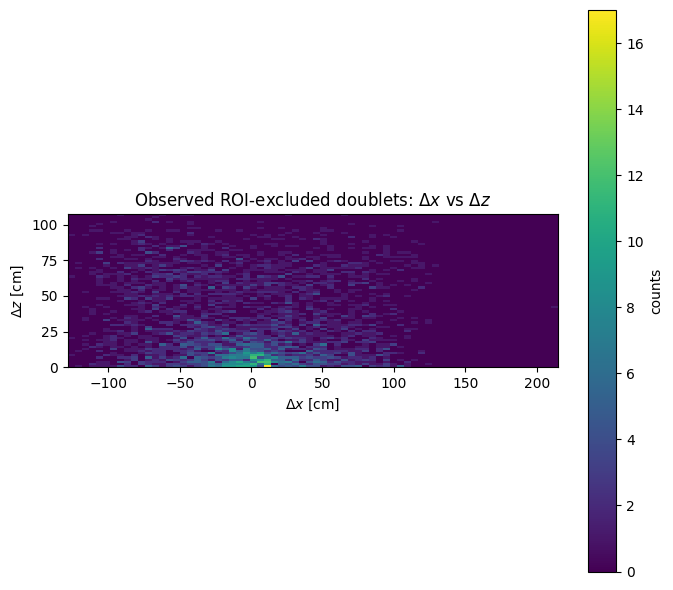

Saved: double_blip_figures/002_Observed_ROI-excluded_doublets_Delta_z_vs_Delta_y.png


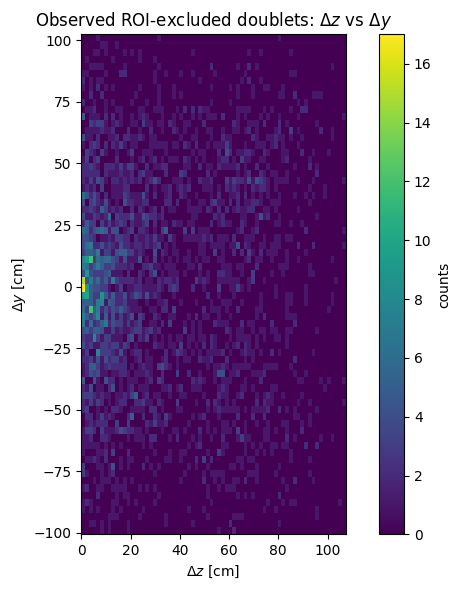

Saved: double_blip_figures/003_Singles-driven_MC_ROI-excluded_Delta_x_vs_Delta_z.png


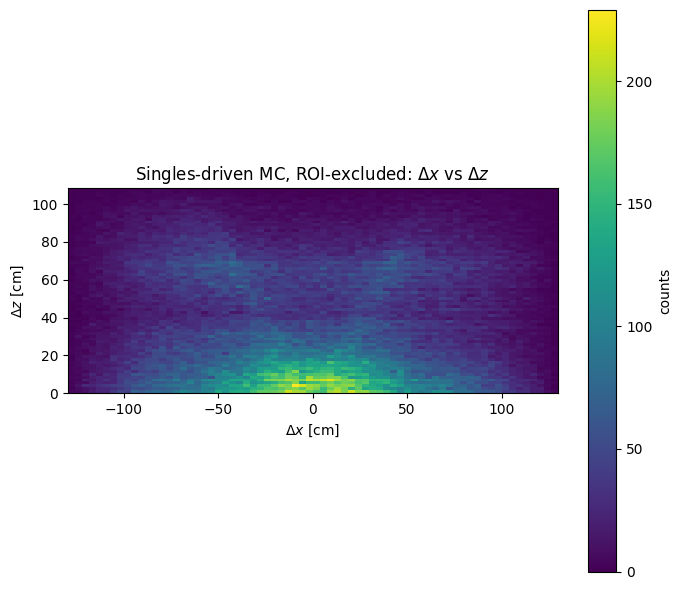

Saved: double_blip_figures/004_Singles-driven_MC_ROI-excluded_Delta_z_vs_Delta_y.png


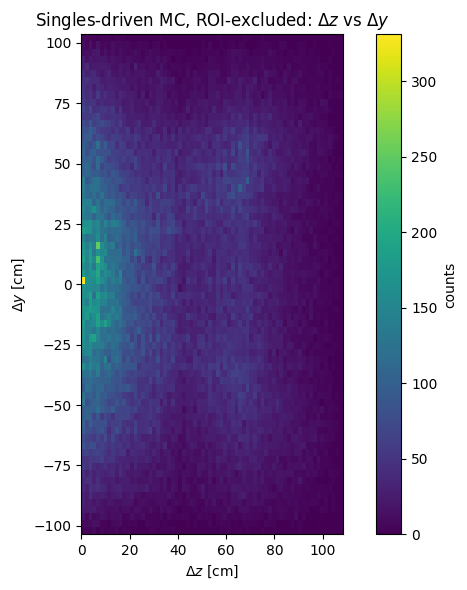

Saved: double_blip_figures/005_theta_zx_observed_vs_singles-driven_MC_after_ROI_exclusion.png


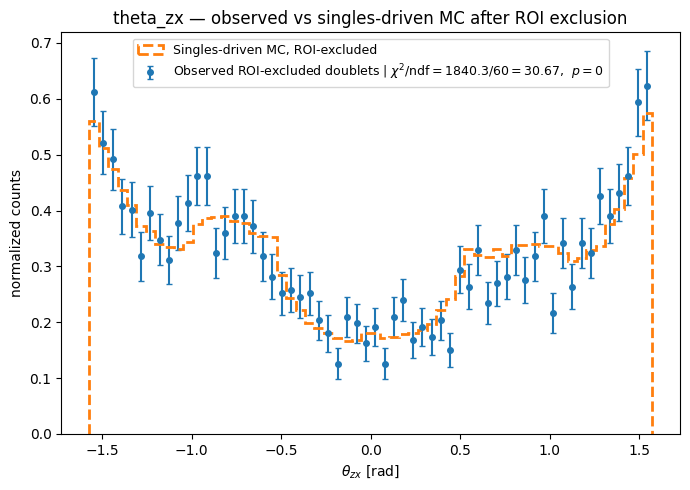

theta_zx — observed vs singles-driven MC after ROI exclusion
  $\chi^2/\mathrm{ndf} = 1840.3/60 = 30.67$,  $p = 0$
  MC expected total from singles = 767
Saved: double_blip_figures/006_theta_zy_observed_vs_singles-driven_MC_after_ROI_exclusion.png


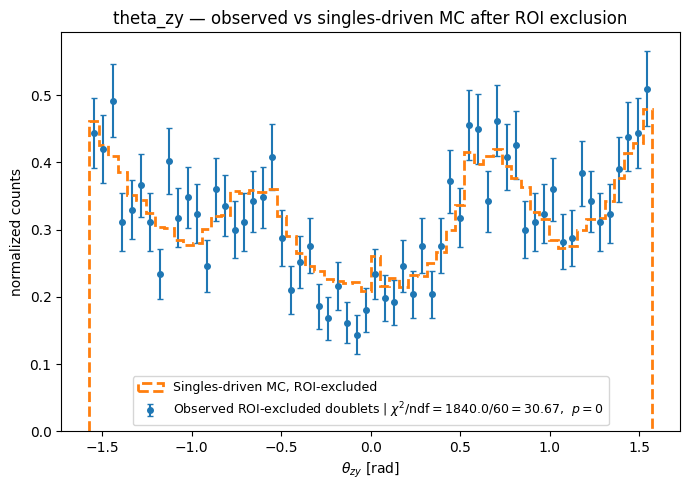

theta_zy — observed vs singles-driven MC after ROI exclusion
  $\chi^2/\mathrm{ndf} = 1840.0/60 = 30.67$,  $p = 0$
  MC expected total from singles = 767
Saved: double_blip_figures/007_theta_z_observed_vs_singles-driven_MC_after_ROI_exclusion.png


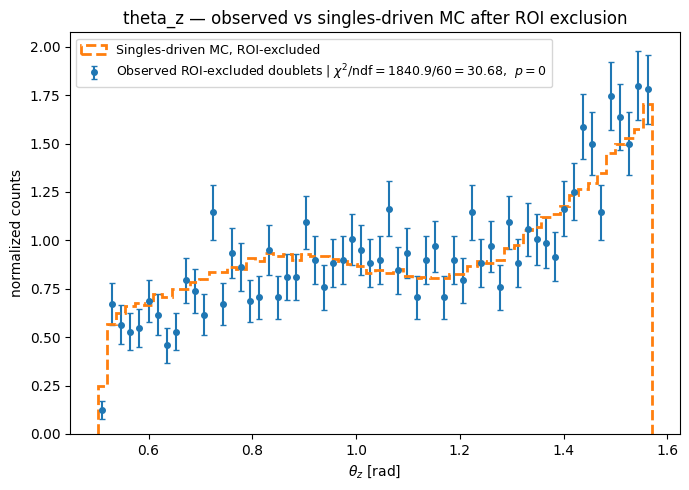

theta_z — observed vs singles-driven MC after ROI exclusion
  $\chi^2/\mathrm{ndf} = 1840.9/60 = 30.68$,  $p = 0$
  MC expected total from singles = 767
Saved: double_blip_figures/008_Projected_doublet_separation_data_vs_singles_driven_MC.png


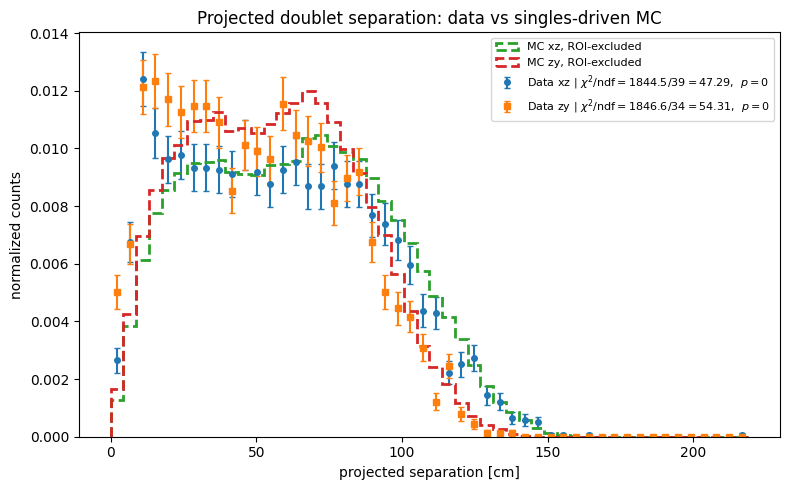

Projected doublet separation: data vs singles-driven MC
  xz: $\chi^2/\mathrm{ndf} = 1844.5/39 = 47.29$,  $p = 0$
  zy: $\chi^2/\mathrm{ndf} = 1846.6/34 = 54.31$,  $p = 0$
  MC expected total from singles = 767
Saved: double_blip_figures/009_Projected_separation_two_panel_comparison_singles_driven_MC.png


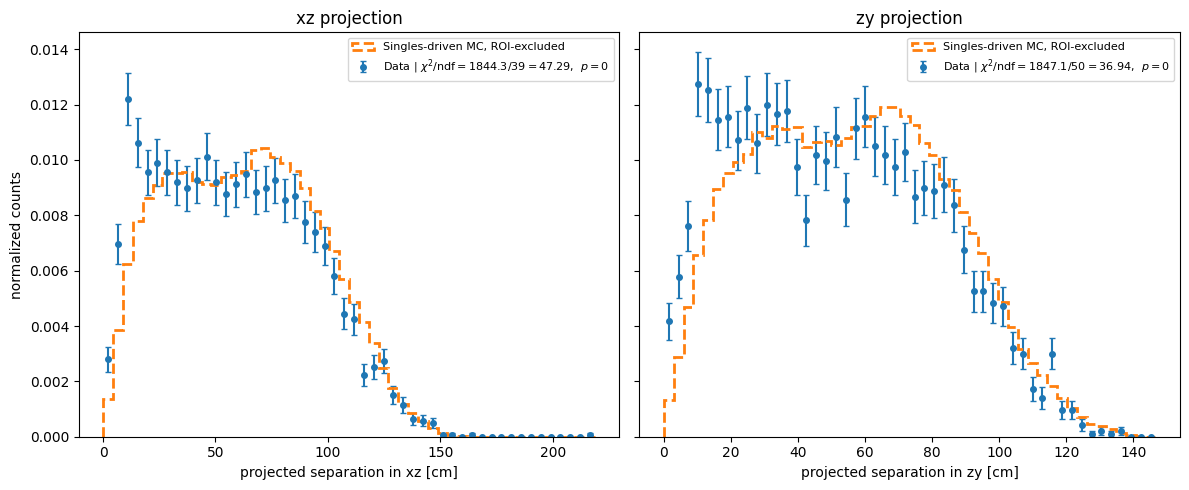

In [18]:
# Cell 7.7 — geometry / angular comparison: observed doublets vs ROI-blinded singles-driven MC

def plot_delta_occupancy_2d(a, b, xlabel, ylabel, title, bins=80, symmetric=True, equal_aspect=True):
    plt.figure(figsize=(7, 6))

    if len(a) == 0 or len(b) == 0:
        print(f"No entries for: {title}")
        return

    if symmetric:
        lim = max(np.max(np.abs(a)), np.max(np.abs(b)))
        ranges = [[-lim, lim], [-lim, lim]]
    else:
        ranges = None

    plt.hist2d(a, b, bins=bins, range=ranges, cmap="viridis")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.colorbar(label="counts")
    if equal_aspect:
        plt.gca().set_aspect("equal", adjustable="box")
    plt.tight_layout()
    save_current_figure(title)
    plt.show()


def plot_all_delta_occupancies(dx, dy, dz, prefix="Sample", bins=80, symmetric=True):
    plot_delta_occupancy_2d(
        dx, dz,
        xlabel=r"$\Delta x$ [cm]",
        ylabel=r"$\Delta z$ [cm]",
        title=f"{prefix}: $\Delta x$ vs $\Delta z$",
        bins=bins,
        symmetric=symmetric,
    )

    plot_delta_occupancy_2d(
        dz, dy,
        xlabel=r"$\Delta z$ [cm]",
        ylabel=r"$\Delta y$ [cm]",
        title=f"{prefix}: $\Delta z$ vs $\Delta y$",
        bins=bins,
        symmetric=symmetric,
    )


def projected_separations(dx, dy, dz):
    rho_xz = np.sqrt(dx*dx + dz*dz)
    rho_zy = np.sqrt(dz*dz + dy*dy)
    return rho_xz, rho_zy


def overlay_projected_separations(
    rho_xz_data, rho_zy_data, rho_xz_mc, rho_zy_mc,
    bins=50,
    model_expected_total=None,
):
    """
    Projected-separation overlay.

    MC is not sideband-normalized to data. If model_expected_total is provided,
    the chi2 uses the singles-based expected MC normalization.
    """
    fig, ax = plt.subplots(figsize=(8, 5))

    allv = np.concatenate([rho_xz_data, rho_zy_data, rho_xz_mc, rho_zy_mc])
    edges = np.linspace(float(np.min(allv)), float(np.max(allv)), bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    widths = np.diff(edges)

    def _density_with_err(data):
        counts, _ = np.histogram(data, bins=edges)
        dens = counts / (max(len(data), 1) * widths)
        err = np.sqrt(counts) / (max(len(data), 1) * widths)
        return counts, dens, err

    c_xz_d, d_xz_d, e_xz_d = _density_with_err(rho_xz_data)
    c_zy_d, d_zy_d, e_zy_d = _density_with_err(rho_zy_data)
    c_xz_m, _, _ = _density_with_err(rho_xz_mc)
    c_zy_m, _, _ = _density_with_err(rho_zy_mc)

    if model_expected_total is not None:
        model_xz = _model_counts_from_expected_total(c_xz_m, model_expected_total)
        model_zy = _model_counts_from_expected_total(c_zy_m, model_expected_total)
        chi2_xz, ndf_xz, p_xz, _ = chi2_ndf_pvalue_from_hists(c_xz_d, model_xz, n_fit_params=0)
        chi2_zy, ndf_zy, p_zy, _ = chi2_ndf_pvalue_from_hists(c_zy_d, model_zy, n_fit_params=0)
        label_xz = fr"Data xz | {_stats_label(chi2_xz, ndf_xz, p_xz)}"
        label_zy = fr"Data zy | {_stats_label(chi2_zy, ndf_zy, p_zy)}"
    else:
        label_xz = "Data xz | shape-only"
        label_zy = "Data zy | shape-only"

    ax.errorbar(centers, d_xz_d, yerr=e_xz_d, fmt="o", markersize=4, capsize=2, label=label_xz)
    ax.errorbar(centers, d_zy_d, yerr=e_zy_d, fmt="s", markersize=4, capsize=2, label=label_zy)

    ax.hist(rho_xz_mc, bins=edges, density=True, histtype="step", linewidth=2, linestyle="--",
            label=r"MC xz, ROI-excluded")
    ax.hist(rho_zy_mc, bins=edges, density=True, histtype="step", linewidth=2, linestyle="--",
            label=r"MC zy, ROI-excluded")

    ax.set_xlabel("projected separation [cm]")
    ax.set_ylabel("normalized counts")
    ax.set_title("Projected doublet separation: data vs singles-driven MC")
    ax.legend(fontsize=8)
    plt.tight_layout()
    save_current_figure("Projected_doublet_separation_data_vs_singles_driven_MC")
    plt.show()

    if model_expected_total is not None:
        print("Projected doublet separation: data vs singles-driven MC")
        print(f"  xz: {_stats_label(chi2_xz, ndf_xz, p_xz)}")
        print(f"  zy: {_stats_label(chi2_zy, ndf_zy, p_zy)}")
        print(f"  MC expected total from singles = {float(model_expected_total):.3g}")


def two_panel_projected_comparison(
    rho_xz_data, rho_zy_data, rho_xz_mc, rho_zy_mc,
    bins=50,
    model_expected_total=None,
):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    datasets = [
        (axes[0], rho_xz_data, rho_xz_mc, "xz projection", "projected separation in xz [cm]"),
        (axes[1], rho_zy_data, rho_zy_mc, "zy projection", "projected separation in zy [cm]"),
    ]

    for ax, data, mc, title, xlabel in datasets:
        allv = np.concatenate([data, mc])
        edges = np.linspace(float(np.min(allv)), float(np.max(allv)), bins + 1)
        centers = 0.5 * (edges[:-1] + edges[1:])
        widths = np.diff(edges)

        counts_d, _ = np.histogram(data, bins=edges)
        counts_m, _ = np.histogram(mc, bins=edges)

        dens_d = counts_d / (max(len(data), 1) * widths)
        err_d = np.sqrt(counts_d) / (max(len(data), 1) * widths)

        if model_expected_total is not None:
            model_m = _model_counts_from_expected_total(counts_m, model_expected_total)
            chi2, ndf, pval, _ = chi2_ndf_pvalue_from_hists(counts_d, model_m, n_fit_params=0)
            stats = _stats_label(chi2, ndf, pval)
        else:
            stats = "shape-only"

        ax.errorbar(centers, dens_d, yerr=err_d, fmt="o", markersize=4, capsize=2,
                    label=f"Data | {stats}")
        ax.hist(mc, bins=edges, density=True, histtype="step", linewidth=2, linestyle="--",
                label="Singles-driven MC, ROI-excluded")
        ax.set_xlabel(xlabel)
        ax.set_title(title)
        ax.legend(fontsize=8)

    axes[0].set_ylabel("normalized counts")
    plt.tight_layout()
    save_current_figure("Projected_separation_two_panel_comparison_singles_driven_MC")
    plt.show()


plot_all_delta_occupancies(
    obs_doublets["dx"], obs_doublets["dy"], obs_doublets["dz"],
    prefix="Observed ROI-excluded doublets", bins=70, symmetric=False,
)
plot_all_delta_occupancies(
    singles_mc["dx"], singles_mc["dy"], singles_mc["dz"],
    prefix="Singles-driven MC, ROI-excluded", bins=70, symmetric=False,
)

overlay_hist_simple(
    obs_doublets["theta_zx"], singles_mc["theta_zx"],
    "Observed ROI-excluded doublets", "Singles-driven MC, ROI-excluded",
    title="theta_zx — observed vs singles-driven MC after ROI exclusion",
    xlabel=r"$\theta_{zx}$ [rad]", bins=60,
    model_expected_total=EXPECTED_SINGLES_MC_VISIBLE,
)

overlay_hist_simple(
    obs_doublets["theta_zy"], singles_mc["theta_zy"],
    "Observed ROI-excluded doublets", "Singles-driven MC, ROI-excluded",
    title="theta_zy — observed vs singles-driven MC after ROI exclusion",
    xlabel=r"$\theta_{zy}$ [rad]", bins=60,
    model_expected_total=EXPECTED_SINGLES_MC_VISIBLE,
)

overlay_hist_simple(
    obs_doublets["theta_z"], singles_mc["theta_z"],
    "Observed ROI-excluded doublets", "Singles-driven MC, ROI-excluded",
    title="theta_z — observed vs singles-driven MC after ROI exclusion",
    xlabel=r"$\theta_{z}$ [rad]", bins=60,
    model_expected_total=EXPECTED_SINGLES_MC_VISIBLE,
)

rho_xz_obs, rho_zy_obs = projected_separations(obs_doublets["dx"], obs_doublets["dy"], obs_doublets["dz"])
rho_xz_smc, rho_zy_smc = projected_separations(singles_mc["dx"], singles_mc["dy"], singles_mc["dz"])

overlay_projected_separations(
    rho_xz_obs, rho_zy_obs, rho_xz_smc, rho_zy_smc,
    bins=50,
    model_expected_total=EXPECTED_SINGLES_MC_VISIBLE,
)

two_panel_projected_comparison(
    rho_xz_obs, rho_zy_obs, rho_xz_smc, rho_zy_smc,
    bins=50,
    model_expected_total=EXPECTED_SINGLES_MC_VISIBLE,
)


### Cell 7.8 — energy / cluster-size comparison: observed doublets vs singles-driven MC

If a charge-like per-hit quantity is available in the input HDF5, these plots compare the observed doublet energy structure against the singles-driven combinatorial expectation.



Energy/size comparison for modern clustering
Saved: double_blip_figures/010_Total_cluster_size_npts_modern_clustering.png


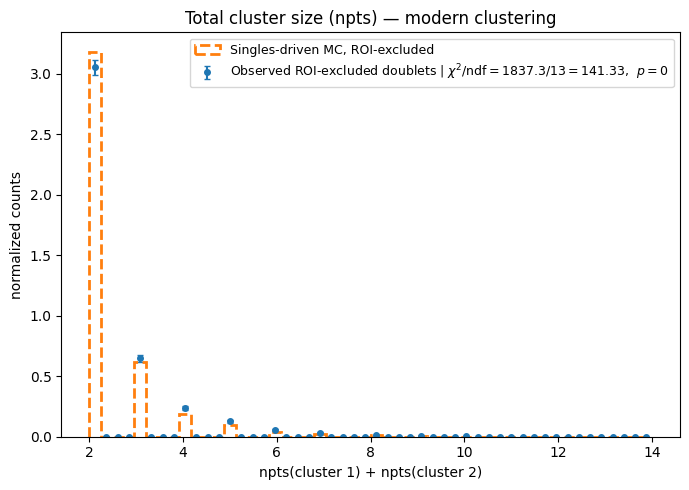

Total cluster size (npts) — modern clustering
  $\chi^2/\mathrm{ndf} = 1837.3/13 = 141.33$,  $p = 0$
  MC expected total from singles = 767
Saved: double_blip_figures/011_Pair_energy_charge_sum_modern_clustering.png


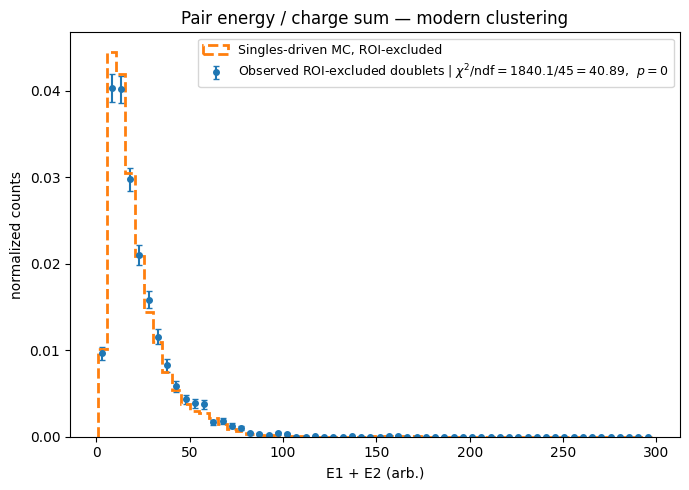

Pair energy / charge sum — modern clustering
  $\chi^2/\mathrm{ndf} = 1840.1/45 = 40.89$,  $p = 0$
  MC expected total from singles = 767
Saved: double_blip_figures/012_E2_-_E1_modern_clustering.png


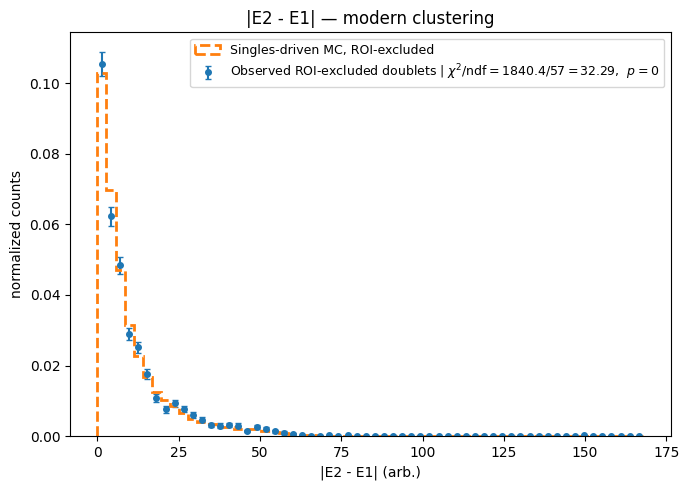

|E2 - E1| — modern clustering
  $\chi^2/\mathrm{ndf} = 1840.4/57 = 32.29$,  $p = 0$
  MC expected total from singles = 767


In [19]:
# Cell 7.8 — energy / cluster-size comparison: observed doublets vs ROI-blinded singles-driven MC
label = "modern clustering"
obs = obs_doublets
smc = singles_mc

print(f"\nEnergy/size comparison for {label}")

overlay_hist_simple(
    obs["npts0"] + obs["npts1"], smc["npts0"] + smc["npts1"],
    "Observed ROI-excluded doublets", "Singles-driven MC, ROI-excluded",
    title=f"Total cluster size (npts) — {label}",
    xlabel="npts(cluster 1) + npts(cluster 2)", bins=50,
    model_expected_total=EXPECTED_SINGLES_MC_VISIBLE,
)

if np.isfinite(obs["esum"]).sum() > 0 and np.isfinite(smc["esum"]).sum() > 0:
    overlay_hist_simple(
        obs["esum"], smc["esum"],
        "Observed ROI-excluded doublets", "Singles-driven MC, ROI-excluded",
        title=f"Pair energy / charge sum — {label}",
        xlabel="E1 + E2 (arb.)", bins=60,
        model_expected_total=EXPECTED_SINGLES_MC_VISIBLE,
    )
    overlay_hist_simple(
        obs["eabsdiff"], smc["eabsdiff"],
        "Observed ROI-excluded doublets", "Singles-driven MC, ROI-excluded",
        title=f"|E2 - E1| — {label}",
        xlabel="|E2 - E1| (arb.)", bins=60,
        model_expected_total=EXPECTED_SINGLES_MC_VISIBLE,
    )
else:
    print("  No usable per-cluster energy / charge field found; skipping energy plots.")


### Cell 7.9 — old-clustering branch intentionally removed

This branch is disabled so all downstream plots use the public-blinded modern clustering sample only.


In [20]:
# Cell 7.9 — intentionally empty
print("Old DBSCAN comparison branch removed for blinded workflow.")


Old DBSCAN comparison branch removed for blinded workflow.


# Cell 8 — overlays

Saved: double_blip_figures/013_theta_zx_MC_continuous_vs_public-visible_data.png


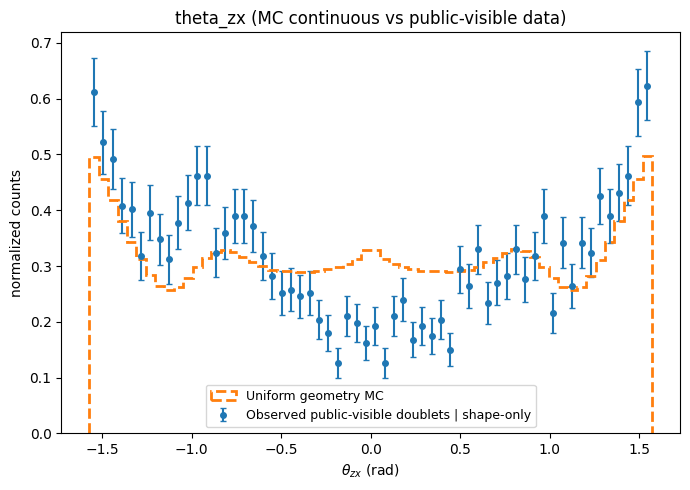

theta_zx (MC continuous vs public-visible data)
  shape-only
Saved: double_blip_figures/014_theta_zy_MC_continuous_vs_public-visible_data.png


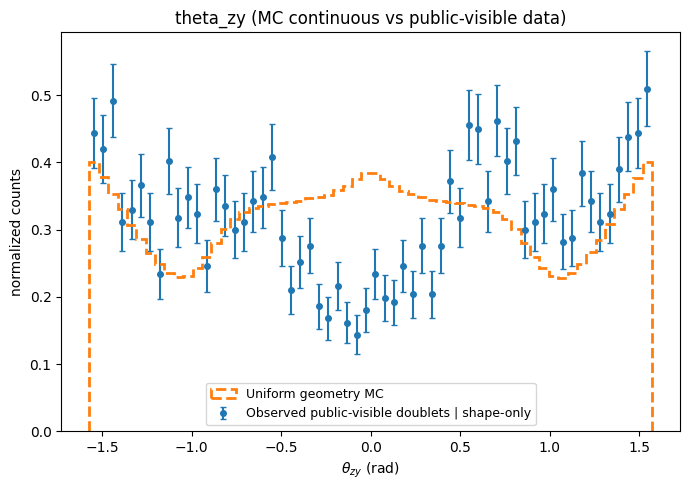

theta_zy (MC continuous vs public-visible data)
  shape-only
Saved: double_blip_figures/015_theta_z_MC_continuous_vs_public-visible_data.png


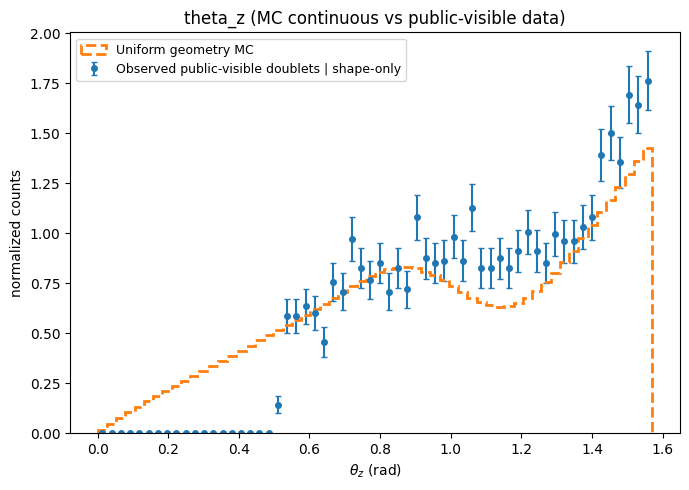

theta_z (MC continuous vs public-visible data)
  shape-only
Saved: double_blip_figures/016_theta_zx_MC_voxelized_vs_public-visible_data.png


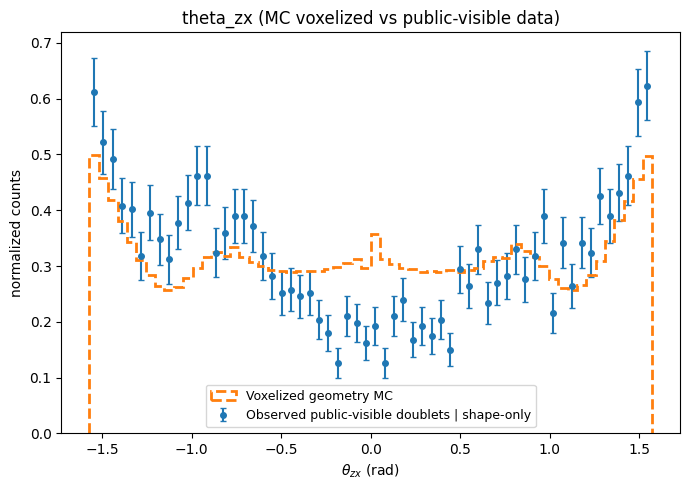

theta_zx (MC voxelized vs public-visible data)
  shape-only
Saved: double_blip_figures/017_theta_zy_MC_voxelized_vs_public-visible_data.png


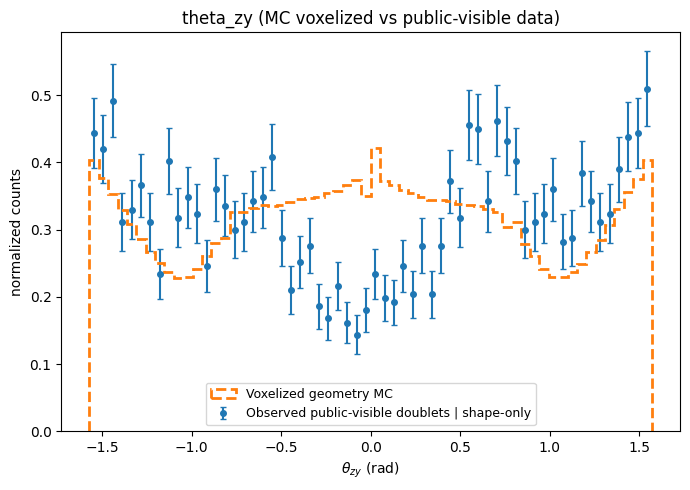

theta_zy (MC voxelized vs public-visible data)
  shape-only
Saved: double_blip_figures/018_theta_z_MC_voxelized_vs_public-visible_data.png


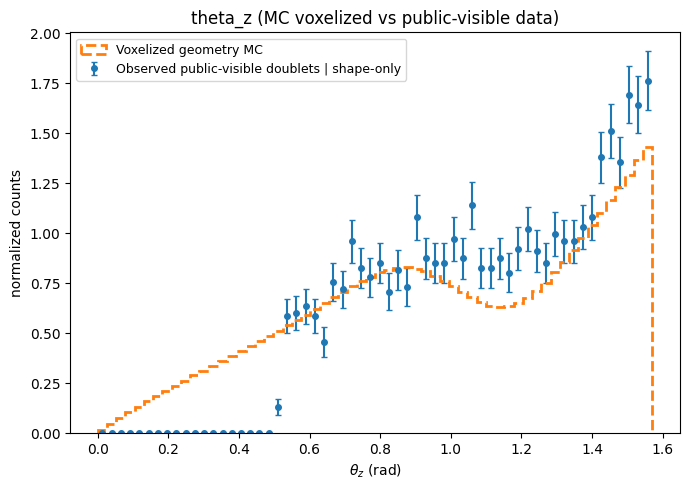

theta_z (MC voxelized vs public-visible data)
  shape-only


In [21]:
# Cell 8 — geometry MC overlays against public-visible data
# These use obs_doublets, so they respect the public blinding mask.

overlay_hist_simple(
    theta_zx_data, theta_zx_mc,
    "Observed public-visible doublets", "Uniform geometry MC",
    title="theta_zx (MC continuous vs public-visible data)",
    xlabel=r"$\theta_{zx}$ (rad)", bins=60,
)
overlay_hist_simple(
    theta_zy_data, theta_zy_mc,
    "Observed public-visible doublets", "Uniform geometry MC",
    title="theta_zy (MC continuous vs public-visible data)",
    xlabel=r"$\theta_{zy}$ (rad)", bins=60,
)
overlay_hist_simple(
    theta_z_data, theta_z_mc,
    "Observed public-visible doublets", "Uniform geometry MC",
    title="theta_z (MC continuous vs public-visible data)",
    xlabel=r"$\theta_{z}$ (rad)", bins=60,
)

overlay_hist_simple(
    theta_zx_data, theta_zx_vox,
    "Observed public-visible doublets", "Voxelized geometry MC",
    title="theta_zx (MC voxelized vs public-visible data)",
    xlabel=r"$\theta_{zx}$ (rad)", bins=60,
)
overlay_hist_simple(
    theta_zy_data, theta_zy_vox,
    "Observed public-visible doublets", "Voxelized geometry MC",
    title="theta_zy (MC voxelized vs public-visible data)",
    xlabel=r"$\theta_{zy}$ (rad)", bins=60,
)
overlay_hist_simple(
    theta_z_data, theta_z_vox,
    "Observed public-visible doublets", "Voxelized geometry MC",
    title="theta_z (MC voxelized vs public-visible data)",
    xlabel=r"$\theta_{z}$ (rad)", bins=60,
)


# Cell 9 — delta-space helpers

`load_data_doublet_deltas(...)` is kept only as a legacy/debug helper. The blinded workflow below builds data deltas from `obs_doublets`, not by reloading raw HDF5 data.


In [22]:

def load_data_doublet_deltas(
    h5_path,
    min_dist=10.0,
    use_centroid=False,
    sort_by_z=False,
):
    """
    Return per-doublet displacement vectors for accepted data events.

    Outputs:
        dx, dy, dz
    where
        dx = x2 - x1
        dy = y2 - y1
        dz = z2 - z1

    If sort_by_z=True, points are ordered so z2 >= z1.
    """
    dxs, dys, dzs = [], [], []

    with h5py.File(h5_path, "r") as f:
        for key in f["events"]:
            g = f["events"][key]
            labels = g["labels"][:]
            x = g["x"][:]
            y = g["y"][:]
            z = g["z"][:]

            geom_mask = (
                (y >= -51.85) & (y <= 51.85) &
                (((z >= 12.68) & (z <= 54.32)) | ((z >= -54.32) & (z <= -12.68)))
            )

            idx = np.where(geom_mask & (labels >= 0))[0]
            if idx.size < 2:
                continue

            labs = labels[idx]
            uniq = np.unique(labs)
            if uniq.size != 2:
                continue

            c0 = idx[labs == uniq[0]]
            c1 = idx[labs == uniq[1]]

            if use_centroid:
                p0 = np.array([x[c0].mean(), y[c0].mean(), z[c0].mean()], dtype=float)
                p1 = np.array([x[c1].mean(), y[c1].mean(), z[c1].mean()], dtype=float)
            else:
                p0 = np.array([x[c0[0]], y[c0[0]], z[c0[0]]], dtype=float)
                p1 = np.array([x[c1[0]], y[c1[0]], z[c1[0]]], dtype=float)

            d = p1 - p0
            dist = np.linalg.norm(d)
            if dist < float(min_dist):
                continue

            if sort_by_z and (p1[2] < p0[2]):
                p0, p1 = p1, p0

            d = p1 - p0
            dxs.append(d[0])
            dys.append(d[1])
            dzs.append(d[2])

    return np.asarray(dxs), np.asarray(dys), np.asarray(dzs)


def deltas_from_stored_tracks(stored_tracks, sort_by_z=False):
    dx, dy, dz = [], [], []

    for t in stored_tracks:
        p0 = np.array([t[0], t[1], t[2]], dtype=float)
        p1 = np.array([t[3], t[4], t[5]], dtype=float)

        if sort_by_z and (p1[2] < p0[2]):
            p0, p1 = p1, p0

        d = p1 - p0
        dx.append(d[0])
        dy.append(d[1])
        dz.append(d[2])

    return np.asarray(dx), np.asarray(dy), np.asarray(dz)


def projected_separations(dx, dy, dz):
    rho_xz = np.sqrt(dx*dx + dz*dz)
    rho_zy = np.sqrt(dz*dz + dy*dy)
    return rho_xz, rho_zy


# Cell 10 — delta-space plotting helpers

In [23]:
def plot_delta_occupancy_2d(a, b, xlabel, ylabel, title, bins=80, symmetric=True, equal_aspect=True):
    plt.figure(figsize=(7, 6))

    if len(a) == 0 or len(b) == 0:
        print(f"No entries for: {title}")
        return

    if symmetric:
        lim = max(np.max(np.abs(a)), np.max(np.abs(b)))
        ranges = [[-lim, lim], [-lim, lim]]
    else:
        ranges = None

    plt.hist2d(a, b, bins=bins, range=ranges, cmap="viridis")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.colorbar(label="counts")
    if equal_aspect:
        plt.gca().set_aspect("equal", adjustable="box")
    plt.tight_layout()
    save_current_figure(title)
    plt.show()


def plot_all_delta_occupancies(dx, dy, dz, prefix="Sample", bins=80, symmetric=True):
    plot_delta_occupancy_2d(
        dx, dz,
        xlabel=r"$\Delta x$ [cm]",
        ylabel=r"$\Delta z$ [cm]",
        title=f"{prefix}: $\Delta x$ vs $\Delta z$",
        bins=bins,
        symmetric=symmetric,
    )

    plot_delta_occupancy_2d(
        dz, dy,
        xlabel=r"$\Delta z$ [cm]",
        ylabel=r"$\Delta y$ [cm]",
        title=f"{prefix}: $\Delta z$ vs $\Delta y$",
        bins=bins,
        symmetric=symmetric,
    )


def plot_projected_separations(rho_xz, rho_zy, title="Projected doublet separation", bins=50, density=False):
    plt.figure(figsize=(7, 5))
    plt.hist(rho_xz, bins=bins, density=density, histtype="step", linewidth=2,
             label=r"$\sqrt{\Delta x^2 + \Delta z^2}$")
    plt.hist(rho_zy, bins=bins, density=density, histtype="step", linewidth=2,
             label=r"$\sqrt{\Delta z^2 + \Delta y^2}$")
    plt.xlabel("projected separation [cm]")
    plt.ylabel("normalized counts" if density else "counts")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    save_current_figure(title)
    plt.show()


def overlay_projected_separations(
    rho_xz_data, rho_zy_data, rho_xz_mc, rho_zy_mc,
    title="",
    bins=50,
    model_expected_total=None,
):
    """
    Projected separation overlay with no sideband normalization.

    If model_expected_total is provided, the MC is scaled to the singles-based
    expected total. Otherwise this is shape-only.
    """
    fig, ax = plt.subplots(figsize=(8, 5))

    allv = np.concatenate([rho_xz_data, rho_zy_data, rho_xz_mc, rho_zy_mc])
    edges = np.linspace(float(np.min(allv)), float(np.max(allv)), bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    widths = np.diff(edges)

    def _density_with_err(data):
        counts, _ = np.histogram(data, bins=edges)
        dens = counts / (max(len(data), 1) * widths)
        err = np.sqrt(counts) / (max(len(data), 1) * widths)
        return counts, dens, err

    c_xz_d, d_xz_d, e_xz_d = _density_with_err(rho_xz_data)
    c_zy_d, d_zy_d, e_zy_d = _density_with_err(rho_zy_data)
    c_xz_m, _, _ = _density_with_err(rho_xz_mc)
    c_zy_m, _, _ = _density_with_err(rho_zy_mc)

    if model_expected_total is not None:
        model_xz = _model_counts_from_expected_total(c_xz_m, model_expected_total)
        model_zy = _model_counts_from_expected_total(c_zy_m, model_expected_total)
        chi2_xz, ndf_xz, p_xz, _ = chi2_ndf_pvalue_from_hists(c_xz_d, model_xz, n_fit_params=0)
        chi2_zy, ndf_zy, p_zy, _ = chi2_ndf_pvalue_from_hists(c_zy_d, model_zy, n_fit_params=0)
        label_xz = fr"Data xz | {_stats_label(chi2_xz, ndf_xz, p_xz)}"
        label_zy = fr"Data zy | {_stats_label(chi2_zy, ndf_zy, p_zy)}"
    else:
        label_xz = "Data xz | shape-only"
        label_zy = "Data zy | shape-only"

    ax.errorbar(centers, d_xz_d, yerr=e_xz_d, fmt="o", markersize=4, capsize=2, label=label_xz)
    ax.errorbar(centers, d_zy_d, yerr=e_zy_d, fmt="s", markersize=4, capsize=2, label=label_zy)

    ax.hist(rho_xz_mc, bins=edges, density=True, histtype="step", linewidth=2, linestyle="--",
            label=r"Singles-driven MC xz")
    ax.hist(rho_zy_mc, bins=edges, density=True, histtype="step", linewidth=2, linestyle="--",
            label=r"Singles-driven MC zy")

    ax.set_xlabel("projected separation [cm]")
    ax.set_ylabel("normalized counts")
    ax.set_title(f"Projected doublet separation: data vs singles-driven MC - {title}")
    ax.legend(fontsize=8)
    plt.tight_layout()
    save_current_figure(f"Projected_doublet_separation_data_vs_singles_MC_{title}")
    plt.show()


def two_panel_projected_comparison(
    rho_xz_data, rho_zy_data, rho_xz_mc, rho_zy_mc,
    titleGeneral="",
    bins=50,
    model_expected_total=None,
):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    datasets = [
        (axes[0], rho_xz_data, rho_xz_mc, "xz projection", "projected separation in xz [cm]"),
        (axes[1], rho_zy_data, rho_zy_mc, "zy projection", "projected separation in zy [cm]"),
    ]

    for ax, data, mc, title, xlabel in datasets:
        allv = np.concatenate([data, mc])
        edges = np.linspace(float(np.min(allv)), float(np.max(allv)), bins + 1)
        centers = 0.5 * (edges[:-1] + edges[1:])
        widths = np.diff(edges)

        counts_d, _ = np.histogram(data, bins=edges)
        counts_m, _ = np.histogram(mc, bins=edges)

        dens_d = counts_d / (max(len(data), 1) * widths)
        err_d = np.sqrt(counts_d) / (max(len(data), 1) * widths)

        if model_expected_total is not None:
            model_m = _model_counts_from_expected_total(counts_m, model_expected_total)
            chi2, ndf, pval, _ = chi2_ndf_pvalue_from_hists(counts_d, model_m, n_fit_params=0)
            stats = _stats_label(chi2, ndf, pval)
        else:
            stats = "shape-only"

        ax.errorbar(centers, dens_d, yerr=err_d, fmt="o", markersize=4, capsize=2,
                    label=f"Data | {stats}")
        ax.hist(mc, bins=edges, density=True, histtype="step", linewidth=2, linestyle="--",
                label="Singles-driven MC")
        ax.set_xlabel(xlabel)
        ax.set_title(title)
        ax.legend(fontsize=8)

    axes[0].set_ylabel("normalized counts")
    plt.tight_layout()
    plt.suptitle(titleGeneral)
    save_current_figure(f"Projected_separation_two_panel_comparison_{titleGeneral}")
    plt.show()


def ratio_projected_zy_over_xz(rho_xz_data, rho_zy_data, rho_xz_mc, rho_zy_mc, title="", nbins=40):
    maxv = max(np.max(rho_xz_data), np.max(rho_zy_data), np.max(rho_xz_mc), np.max(rho_zy_mc))
    bins = np.linspace(0, maxv, nbins)

    h_xz_data, _ = np.histogram(rho_xz_data, bins=bins, density=True)
    h_zy_data, _ = np.histogram(rho_zy_data, bins=bins, density=True)
    h_xz_mc,   _ = np.histogram(rho_xz_mc,   bins=bins, density=True)
    h_zy_mc,   _ = np.histogram(rho_zy_mc,   bins=bins, density=True)

    centers = 0.5 * (bins[:-1] + bins[1:])
    eps = 1e-12

    ratio_data = h_zy_data / (h_xz_data + eps)
    ratio_mc   = h_zy_mc   / (h_xz_mc   + eps)

    plt.figure(figsize=(7, 5))
    plt.plot(centers, ratio_data, marker="o", label="Data: zy / xz")
    plt.plot(centers, ratio_mc, marker="o", label="Singles-driven MC: zy / xz")
    plt.axhline(1.0, color="k", linestyle="--", alpha=0.5)
    plt.xlabel("projected separation [cm]")
    plt.ylabel("ratio")
    plt.title(f"Relative suppression/enhancement: zy vs xz - {title}")
    plt.legend()
    plt.tight_layout()
    save_current_figure(f"Projected_separation_ratio_zy_over_xz_{title}")
    plt.show()


<>:31: SyntaxWarning: invalid escape sequence '\D'
<>:40: SyntaxWarning: invalid escape sequence '\D'
<>:31: SyntaxWarning: invalid escape sequence '\D'
<>:40: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_2166/2977890110.py:31: SyntaxWarning: invalid escape sequence '\D'
  title=f"{prefix}: $\Delta x$ vs $\Delta z$",
/tmp/ipykernel_2166/2977890110.py:40: SyntaxWarning: invalid escape sequence '\D'
  title=f"{prefix}: $\Delta z$ vs $\Delta y$",


# Cell 11 — build delta-space samples from public-visible data and MC

The data deltas come from `obs_doublets`, so they respect the public blinding mask.


In [24]:
# Cell 11 — build delta-space samples from public-visible data and ROI-blinded singles-driven MC

# Ordered-by-z version comes directly from the public-visible observed doublets.
dx_data_ord = obs_doublets["dx"]
dy_data_ord = obs_doublets["dy"]
dz_data_ord = obs_doublets["dz"]

dx_mc_ord = singles_mc["dx"]
dy_mc_ord = singles_mc["dy"]
dz_mc_ord = singles_mc["dz"]

# Signed/unsorted observed version: rebuild candidate arrays without z-ordering,
# then apply the exact same public observed mask.
_obs_doublets_unordered_for_mask_join = build_doublet_arrays_from_cluster_pairs(
    summary["doublets"],
    min_dist=min_dist,
    sort_by_z=False,
)
obs_doublets_unordered = apply_public_blinding_to_doublet_arrays(
    _obs_doublets_unordered_for_mask_join,
    BLINDING_MASK_H5,
    label="modern clustering observed doublets, unordered deltas",
    strict=STRICT_BLINDING_MASK,
    use_public_blinding=USE_PUBLIC_BLINDING,
)

# Signed/unsorted singles-driven MC version: regenerate without z-ordering, then
# apply the same circular ROI exclusion.
singles_mc_unordered_pre_roi, singles_mc_unordered_meta = monte_carlo_doublets_from_singles(
    summary["singles"],
    n_accept=SINGLES_MC_TARGET,
    min_dist=min_dist,
    sort_by_z=False,
    seed=10,
    allow_same_source_event=False,
    return_metadata=True,
)

if USE_PUBLIC_BLINDING and APPLY_ROI_TO_SINGLES_MC:
    singles_mc_unordered, singles_mc_unordered_keep = apply_circular_roi_exclusion_to_doublet_arrays(
        singles_mc_unordered_pre_roi,
        theta_radius_deg=ROI_CONFIG["theta_radius_deg"],
        center_zx_deg=ROI_CONFIG["center_zx_deg"],
        center_zy_deg=ROI_CONFIG["center_zy_deg"],
        axis_symmetric=ROI_CONFIG["axis_symmetric_roi"],
        label="singles-driven MC, unordered deltas",
        use_public_blinding=True,
    )
else:
    singles_mc_unordered = singles_mc_unordered_pre_roi
    singles_mc_unordered_keep = np.ones(len(singles_mc_unordered_pre_roi["dx"]), dtype=bool)

dx_data = obs_doublets_unordered["dx"]
dy_data = obs_doublets_unordered["dy"]
dz_data = obs_doublets_unordered["dz"]

dx_mc = singles_mc_unordered["dx"]
dy_mc = singles_mc_unordered["dy"]
dz_mc = singles_mc_unordered["dz"]

# --- projected separations ---
rho_xz_data = np.sqrt(dx_data**2 + dz_data**2)
rho_zy_data = np.sqrt(dz_data**2 + dy_data**2)

rho_xz_mc = np.sqrt(dx_mc**2 + dz_mc**2)
rho_zy_mc = np.sqrt(dz_mc**2 + dy_mc**2)

# Kept for compatibility with later cells; same-module geometry MC is no longer
# part of the active blinded normalization path.
rho_xz_mc_same = rho_xz_mc
rho_zy_mc_same = rho_zy_mc
dx_mc_same, dy_mc_same, dz_mc_same = dx_mc, dy_mc, dz_mc
dx_mc_same_ord, dy_mc_same_ord, dz_mc_same_ord = dx_mc_ord, dy_mc_ord, dz_mc_ord

print("Done building delta-space variables from observed sidebands and ROI-blinded singles-driven MC.")


modern clustering observed doublets, unordered deltas: public candidate mask applied.
singles-driven MC, unordered deltas: circular ROI exclusion applied.
Done building delta-space variables from observed sidebands and ROI-blinded singles-driven MC.


# Cell 12 — delta-space occupancy plots

Saved: double_blip_figures/019_Public-visible_data_signed_deltas_Delta_x_vs_Delta_z.png


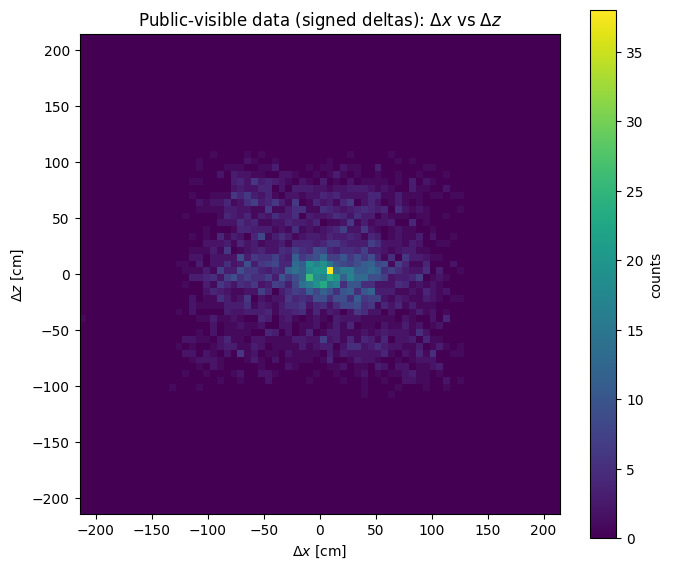

Saved: double_blip_figures/020_Public-visible_data_signed_deltas_Delta_z_vs_Delta_y.png


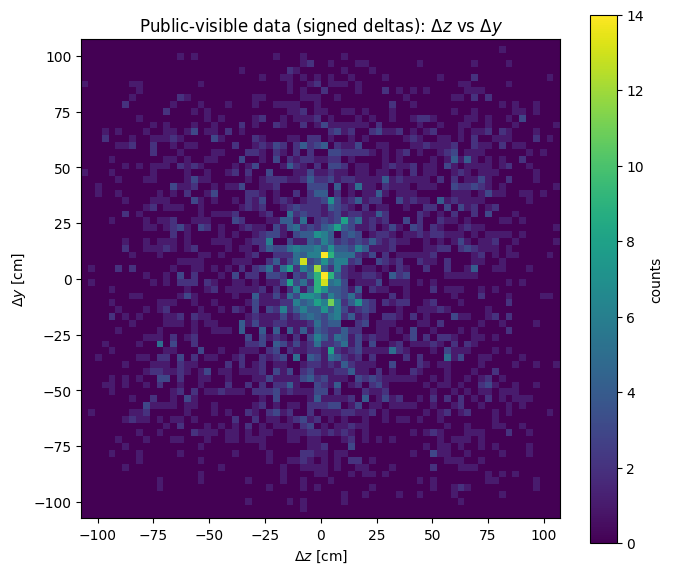

Saved: double_blip_figures/021_MC_continuous_signed_deltas_Delta_x_vs_Delta_z.png


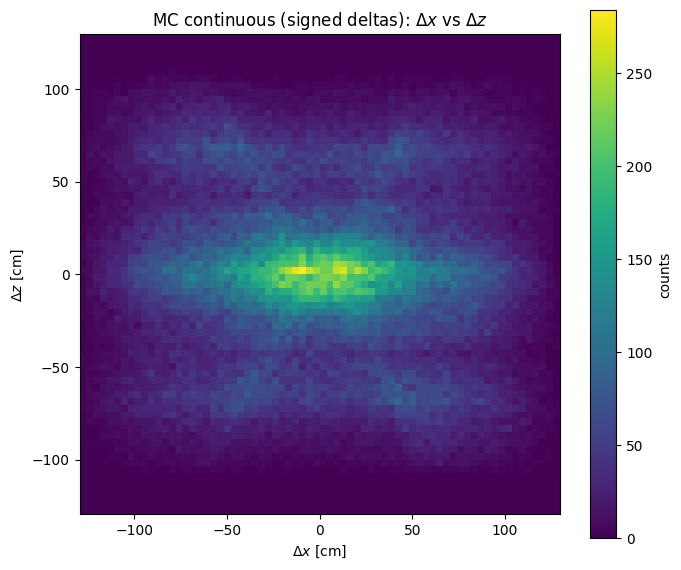

Saved: double_blip_figures/022_MC_continuous_signed_deltas_Delta_z_vs_Delta_y.png


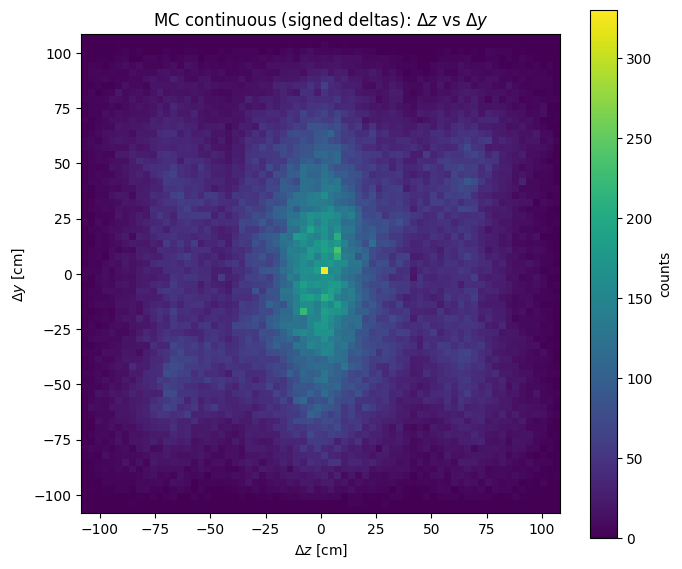

In [25]:
plot_all_delta_occupancies(
    dx_data, dy_data, dz_data,
    prefix="Public-visible data (signed deltas)",
    bins=70,
    symmetric=True,
)

plot_all_delta_occupancies(
    dx_mc, dy_mc, dz_mc,
    prefix="MC continuous (signed deltas)",
    bins=70,
    symmetric=True,
)


# Cell 13 — ordered-by-z delta-space occupancy plots

Ordering each doublet so that $z_2 \ge z_1$ makes $\Delta z \ge 0$ and often gives a cleaner diagnostic view.


Saved: double_blip_figures/023_Public-visible_data_ordered_by_z_Delta_x_vs_Delta_z.png


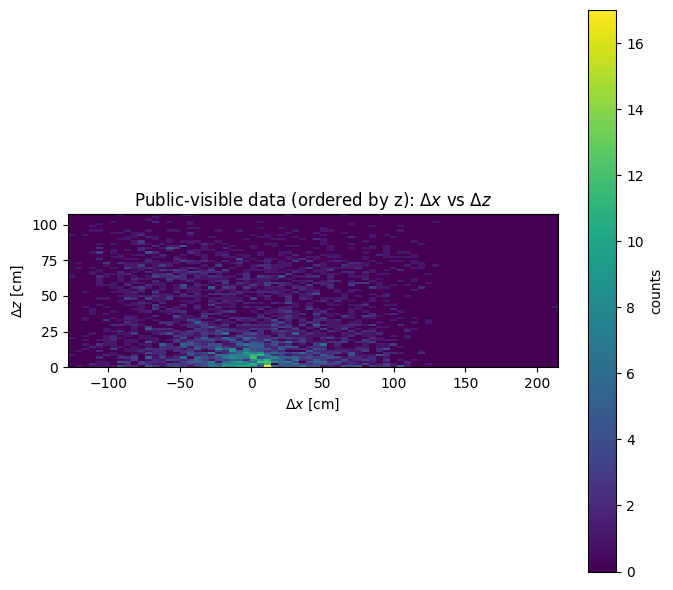

Saved: double_blip_figures/024_Public-visible_data_ordered_by_z_Delta_z_vs_Delta_y.png


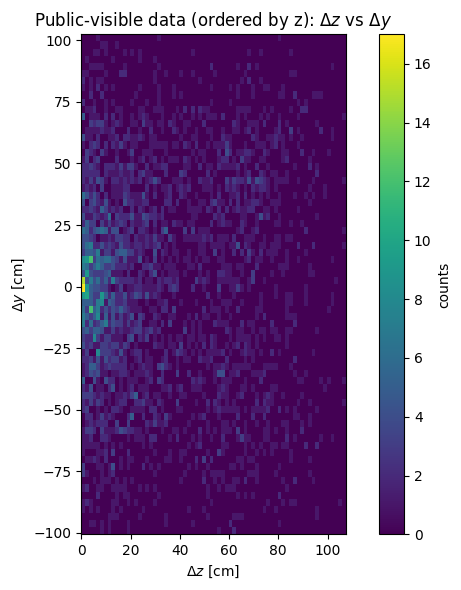

Saved: double_blip_figures/025_MC_continuous_ordered_by_z_Delta_x_vs_Delta_z.png


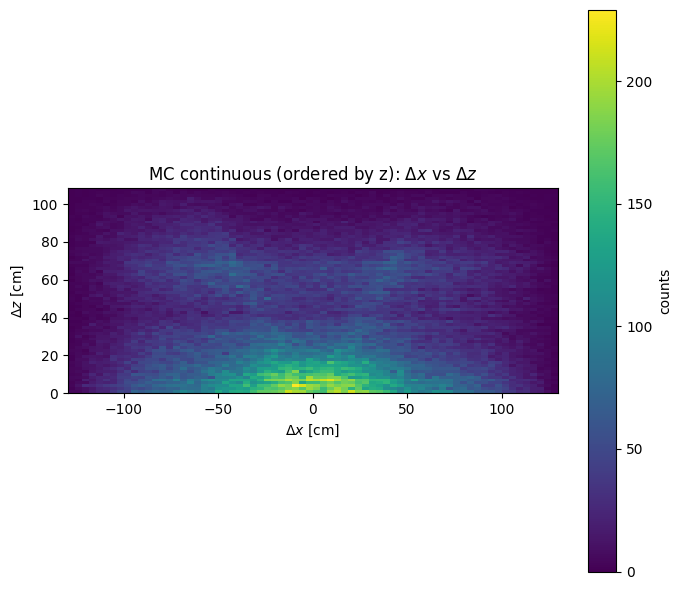

Saved: double_blip_figures/026_MC_continuous_ordered_by_z_Delta_z_vs_Delta_y.png


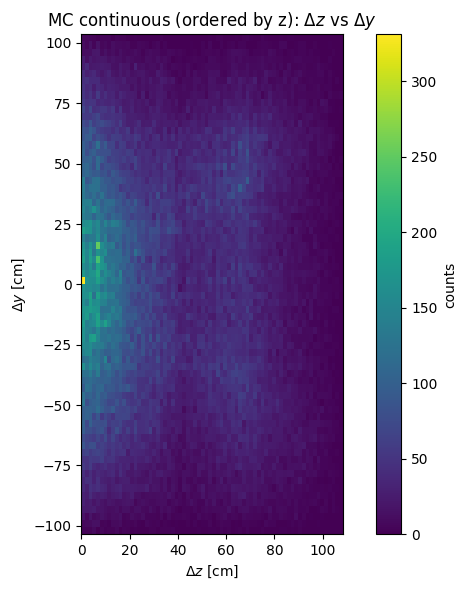

In [26]:
plot_all_delta_occupancies(
    dx_data_ord, dy_data_ord, dz_data_ord,
    prefix="Public-visible data (ordered by z)",
    bins=70,
    symmetric=False,
)

plot_all_delta_occupancies(
    dx_mc_ord, dy_mc_ord, dz_mc_ord,
    prefix="MC continuous (ordered by z)",
    bins=70,
    symmetric=False,
)


# Cell 14 — projected separation plots

The last two blocks compare data against:
- all stored MC doublets
- same-module-only stored MC doublets


Saved: double_blip_figures/027_Observed_ROI-excluded_data_projected_doublet_separation.png


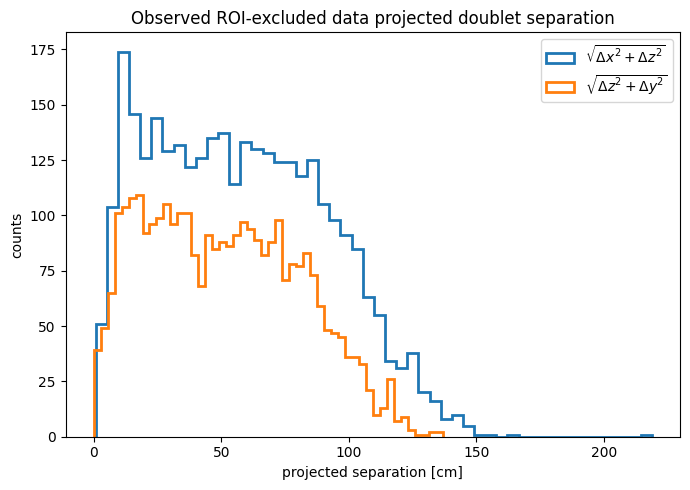

Saved: double_blip_figures/028_ROI-excluded_singles-driven_MC_projected_doublet_separation.png


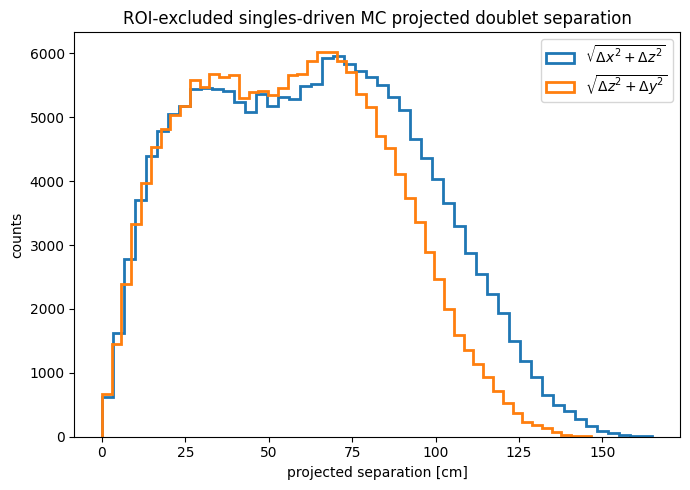

Saved: double_blip_figures/029_Projected_doublet_separation_data_vs_singles_MC_roi_excluded_singles_driven_MC.png


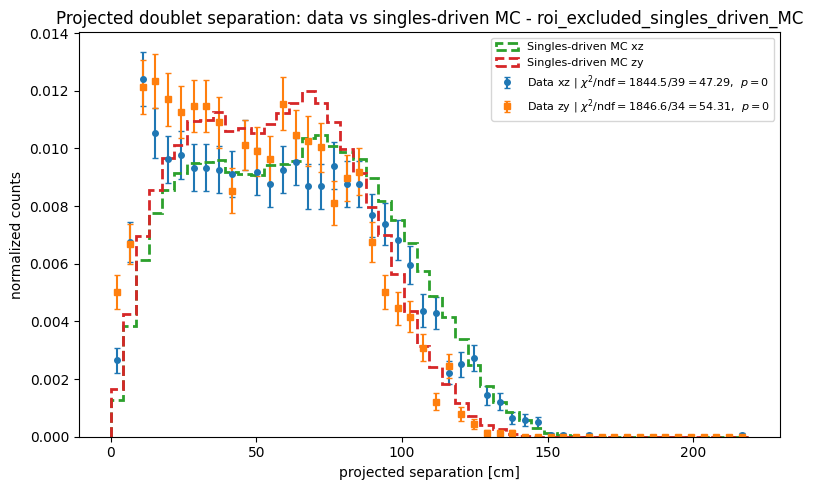

Saved: double_blip_figures/030_Projected_separation_two_panel_comparison_roi_excluded_singles_driven_MC.png


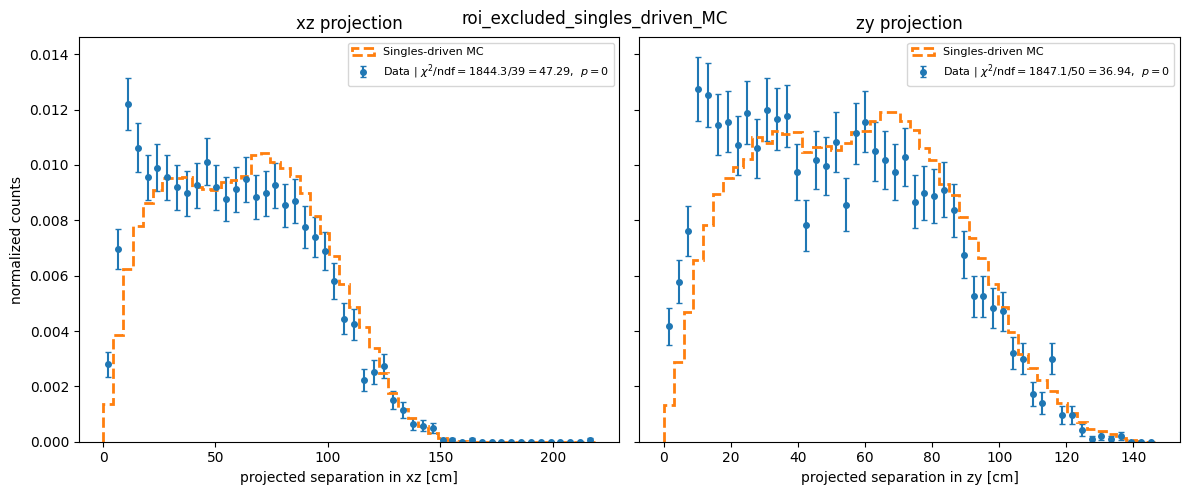

Saved: double_blip_figures/031_Projected_separation_ratio_zy_over_xz_roi_excluded_singles_driven_MC.png


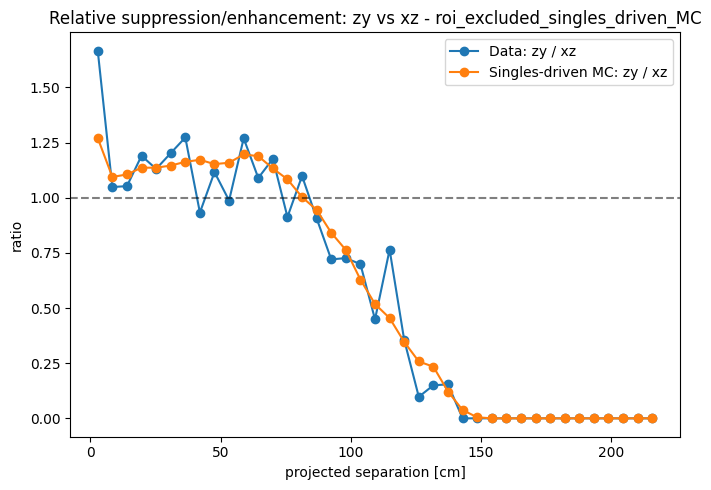

In [27]:
plot_projected_separations(
    rho_xz_data, rho_zy_data,
    title="Observed ROI-excluded data projected doublet separation",
    bins=50,
    density=False,
)

plot_projected_separations(
    rho_xz_mc, rho_zy_mc,
    title="ROI-excluded singles-driven MC projected doublet separation",
    bins=50,
    density=False,
)

overlay_projected_separations(
    rho_xz_data, rho_zy_data,
    rho_xz_mc, rho_zy_mc,
    "roi_excluded_singles_driven_MC",
    bins=50,
    model_expected_total=EXPECTED_SINGLES_MC_VISIBLE,
)

two_panel_projected_comparison(
    rho_xz_data, rho_zy_data,
    rho_xz_mc, rho_zy_mc,
    "roi_excluded_singles_driven_MC",
    bins=50,
    model_expected_total=EXPECTED_SINGLES_MC_VISIBLE,
)

ratio_projected_zy_over_xz(
    rho_xz_data, rho_zy_data,
    rho_xz_mc, rho_zy_mc,
    "roi_excluded_singles_driven_MC",
    nbins=40,
)


Saved: double_blip_figures/032_Projected_angle_space_after_circular_ROI_exclusion.png


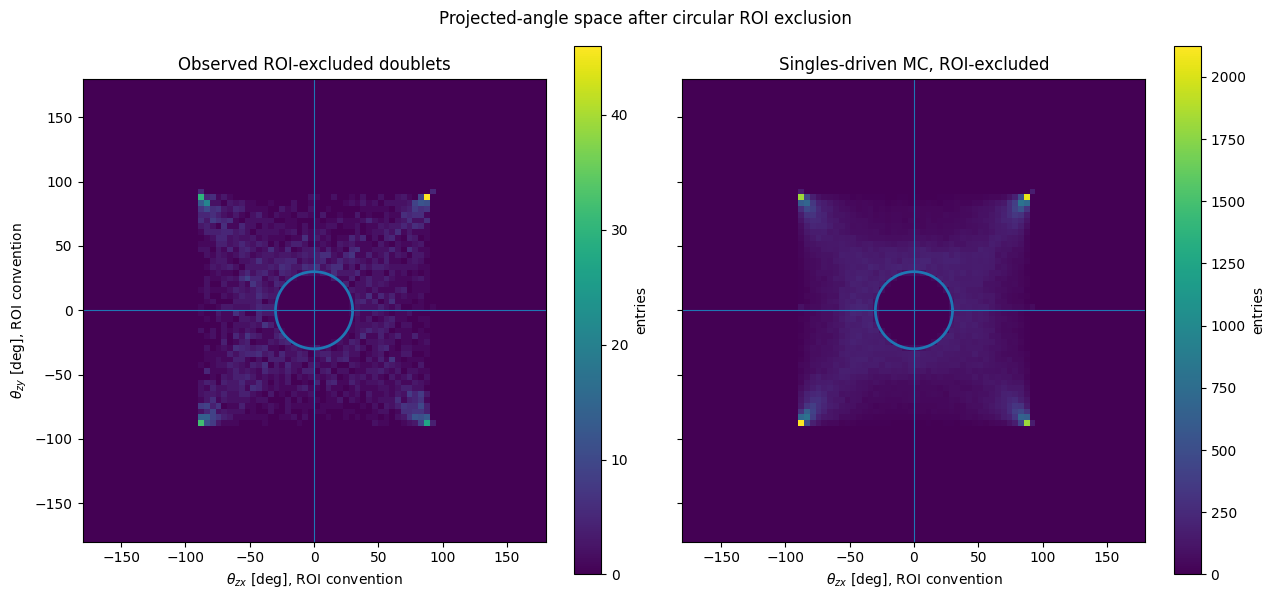

In [28]:
# Cell 7.7b — 2D circular-ROI diagnostic for observed data and singles-driven MC

# This uses the same circular ROI config loaded from the public mask. It is a
# geometry diagnostic only; it does not print pre-mask doublet counts.

if USE_PUBLIC_BLINDING:
    roi_cfg = ROI_CONFIG
else:
    roi_cfg = {
        "theta_radius_deg": 30.0,
        "center_zx_deg": 0.0,
        "center_zy_deg": 0.0,
        "axis_symmetric_roi": True,
    }

def projected_angles_deg_for_plot(obs, roi_cfg):
    theta_zx, theta_zy = axis_symmetric_projected_angles(
        obs["dx"], obs["dy"], obs["dz"],
        axis_symmetric=roi_cfg["axis_symmetric_roi"],
    )
    return np.degrees(theta_zx), np.degrees(theta_zy)

theta_zx_vis, theta_zy_vis = projected_angles_deg_for_plot(obs_doublets, roi_cfg)
theta_zx_smc, theta_zy_smc = projected_angles_deg_for_plot(singles_mc, roi_cfg)

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharex=True, sharey=True)

plots = [
    (axes[0], theta_zx_vis, theta_zy_vis, "Observed ROI-excluded doublets"),
    (axes[1], theta_zx_smc, theta_zy_smc, "Singles-driven MC, ROI-excluded"),
]

theta = np.linspace(0, 2*np.pi, 361)
cx = roi_cfg["center_zx_deg"]
cy = roi_cfg["center_zy_deg"]
rr = roi_cfg["theta_radius_deg"]

for ax, tx, ty, title in plots:
    h = ax.hist2d(
        tx, ty,
        bins=80,
        range=[[-180, 180], [-180, 180]],
        cmap="viridis",
    )
    ax.plot(cx + rr*np.cos(theta), cy + rr*np.sin(theta), linewidth=2)
    ax.axhline(0, linewidth=0.8)
    ax.axvline(0, linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel(r"$\theta_{zx}$ [deg], ROI convention")
    ax.set_aspect("equal", adjustable="box")
    fig.colorbar(h[3], ax=ax, label="entries")

axes[0].set_ylabel(r"$\theta_{zy}$ [deg], ROI convention")
fig.suptitle("Projected-angle space after circular ROI exclusion")
plt.tight_layout()
save_current_figure("Projected_angle_space_after_circular_ROI_exclusion")
plt.show()
